# 카공하기 좋은 카페 추천 지도 — 핵심 데이터 파이프라인

이 파일은 다음 핵심 단계만 포함합니다.
1. 카카오맵 API 카페 기본정보 수집
2. 네이버 플레이스 리뷰·별점·영업시간 수집
3. 카카오·네이버 데이터 매칭 및 분석 대상 필터링
4. 거리·도보시간·프랜차이즈 정보 추가
5. 리뷰 문장 분리 및 카공 특성 태깅
6. 감성 분석 라벨링용 데이터 생성

반복 진단 코드, 파일 삭제 코드, 중복 설치 코드, 임시 규칙 기반 점수 계산은 제외했습니다.

## 0. Colab 환경 설정

카카오 REST API 키는 코드에 직접 작성하지 않습니다.
Colab 보안 비밀에 `KAKAO_REST_API_KEY`로 저장하거나 실행 중 직접 입력합니다.

In [1]:
!pip -q install selenium
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get -qq update
!apt-get -qq install -y ./google-chrome-stable_current_amd64.deb > /dev/null
!google-chrome --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.2 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Google Chrome 149.0.7827.155 


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import difflib
import json
import math
import os
import random
import re
import time
import urllib.parse
from getpass import getpass
from pathlib import Path

import pandas as pd
import requests
from selenium import webdriver
from selenium.common.exceptions import NoSuchFrameException, WebDriverException
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

WORK_DIR = Path('/content/drive/MyDrive/study_cafe_project')
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

YONGIN_UNIV = (37.2342, 127.1869)
GIHEUNG_STN = (37.2747, 127.1158)

N_GRID = 12
RADIUS = 2000
MAX_CAFES = 200
REVIEWS_PER_CAFE = 30
MIN_REVIEWS_PER_CAFE = 5
FORCE_KAKAO_RECOLLECT = False
ALLOWED_MATCH_STATUSES = {'matched'}

print('작업 폴더:', WORK_DIR)

Mounted at /content/drive
작업 폴더: /content/drive/MyDrive/study_cafe_project


## 1. 공통 유틸리티

In [3]:
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'필수 파일이 없습니다: {path}')
    return path

def validate_columns(df, required_columns, df_name='DataFrame'):
    missing = set(required_columns) - set(df.columns)
    if missing:
        raise ValueError(f'{df_name} 필수 컬럼 누락: {sorted(missing)}')


def append_csv(rows, path):
    if not rows:
        return
    path = Path(path)
    pd.DataFrame(rows).to_csv(
        path,
        mode='a',
        index=False,
        encoding='utf-8-sig',
        header=not path.exists(),
    )

def get_kakao_api_key():
    key = None
    try:
        from google.colab import userdata
        key = userdata.get('KAKAO_REST_API_KEY')
    except Exception:
        pass

    if not key:
        key = os.getenv('KAKAO_REST_API_KEY')
    if not key:
        key = getpass('카카오 REST API 키를 입력하세요: ').strip()
    if not key:
        raise ValueError('카카오 REST API 키가 입력되지 않았습니다.')
    return key

## 2. 카카오맵 API — 카페 기본정보 수집

In [4]:
def grid_points(p1, p2, n):
    if n < 2:
        raise ValueError('n은 2 이상이어야 합니다.')
    return [
        (
            p1[0] + (p2[0] - p1[0]) * i / (n - 1),
            p1[1] + (p2[1] - p1[1]) * i / (n - 1),
        )
        for i in range(n)
    ]


def kakao_category_search(api_key, lat, lng, radius, page):
    url = 'https://dapi.kakao.com/v2/local/search/category.json'
    headers = {'Authorization': f'KakaoAK {api_key}'}
    params = {
        'category_group_code': 'CE7',
        'x': lng,
        'y': lat,
        'radius': radius,
        'page': page,
        'size': 15,
        'sort': 'distance',
    }
    response = requests.get(url, headers=headers, params=params, timeout=15)
    response.raise_for_status()
    return response.json()


def collect_kakao_cafes(output_path='cafes_raw.csv', force=False):
    output_path = Path(output_path)
    if output_path.exists() and not force:
        df = pd.read_csv(output_path)
        print(f'기존 파일 사용: {output_path} ({len(df)}개)')
        return df

    api_key = get_kakao_api_key()
    cafes = {}

    for lat, lng in grid_points(YONGIN_UNIV, GIHEUNG_STN, N_GRID):
        for page in range(1, 4):
            data = kakao_category_search(api_key, lat, lng, RADIUS, page)
            for item in data.get('documents', []):
                cafes[item['id']] = {
                    'kakao_place_id': item['id'],
                    'kakao_name': item['place_name'],
                    'address': item['road_address_name'] or item['address_name'],
                    'latitude': float(item['y']),
                    'longitude': float(item['x']),
                    'phone': item.get('phone', ''),
                    'kakao_place_url': item.get('place_url', ''),
                    'category': item.get('category_name', ''),
                }
            if data.get('meta', {}).get('is_end', True):
                break
            time.sleep(0.3)
        print(f'({lat:.4f}, {lng:.4f}) 누적 카페 수: {len(cafes)}')

    if not cafes:
        raise RuntimeError('카카오 API에서 카페가 수집되지 않았습니다.')

    df = pd.DataFrame(cafes.values()).head(MAX_CAFES).reset_index(drop=True)
    df.insert(0, 'cafe_id', [f'C{i:03d}' for i in range(1, len(df) + 1)])
    df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f'저장 완료: {output_path} ({len(df)}개)')
    return df


df_raw = collect_kakao_cafes('cafes_raw.csv', FORCE_KAKAO_RECOLLECT)
df_raw.head()

기존 파일 사용: cafes_raw.csv (100개)


,cafe_id,kakao_place_id,kakao_name,address,latitude,longitude,phone,kakao_place_url
0,C001,507340095,커스텀커피 역북점,경기 용인시 처인구 명지로16번길 9-11,37.233445,127.187132,031-321-8662,http://place.map.kakao.com/507340095
1,C002,2136620254,카페만월경 용인명지대역점,경기 용인시 처인구 명지로16번길 26,37.235056,127.187017,NaN,http://place.map.kakao.com/2136620254
2,C003,1130012648,어웨이크키친 역북점,경기 용인시 처인구 명지로16번길 9-11,37.233300,127.187094,031-339-9130,http://place.map.kakao.com/1130012648
3,C004,554559796,밀크팜747,경기 용인시 처인구 명지로 24,37.233972,127.188023,031-335-8830,http://place.map.kakao.com/554559796
4,C005,189776326,홀홀베이크샵,경기 용인시 처인구 명지로 24,37.233972,127.188023,NaN,http://place.map.kakao.com/189776326


## 3. 네이버 플레이스 — 리뷰·별점·영업시간 수집

In [5]:
SELECTORS = {
    'review_item': [
        'li.place_apply_pui',
        'li.pui__X35jYm',
        'div.place_section_content ul > li',
    ],
    'review_more_btn': [
        'a.fvwqf',
        'div.lfH3O a',
        'a.NSTUp',
        'button',
    ],
}


def make_driver(headless=True):
    options = Options()
    if headless:
        options.add_argument('--headless=new')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--window-size=1400,900')
    options.add_argument('--lang=ko-KR')
    options.add_argument(
        'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36'
    )
    return webdriver.Chrome(options=options)


def find_any(driver, selector_key):
    for css in SELECTORS[selector_key]:
        elements = driver.find_elements(By.CSS_SELECTOR, css)
        if elements:
            return elements, css
    return [], None


def normalize_name(value):
    return re.sub(r'[^0-9a-z가-힣]', '', str(value).lower())


def find_place_id(driver, name, address=''):
    parts = str(address).split()
    region = ' '.join(parts[1:3]) if len(parts) >= 3 else ''
    query = f'{name} {region}'.strip()
    driver.get('https://map.naver.com/p/search/' + urllib.parse.quote(query))
    time.sleep(3.5)

    direct_match = re.search(r'place/(\d+)', driver.current_url)
    if direct_match:
        return direct_match.group(1), query

    try:
        driver.switch_to.frame('searchIframe')
        html = driver.page_source
        pairs = re.findall(
            r'"id"\s*:\s*"(\d{7,12})".{0,300}?"name"\s*:\s*"([^"]+)"',
            html,
            re.S,
        )
        best_id, best_similarity = None, 0.0
        for place_id, candidate_name in pairs:
            similarity = difflib.SequenceMatcher(
                None,
                normalize_name(name),
                normalize_name(candidate_name),
            ).ratio()
            if similarity > best_similarity:
                best_id, best_similarity = place_id, similarity

        if best_id and best_similarity >= 0.4:
            return best_id, query

        ids = re.findall(r'"id"\s*:\s*"(\d{9,12})"', html)
        return (ids[0] if ids else None), query

    except (NoSuchFrameException, WebDriverException):
        return None, query
    finally:
        driver.switch_to.default_content()


def open_place_page(driver, place_id, tab='home'):
    for place_kind in ['cafe', 'restaurant', 'place']:
        driver.get(f'https://pcmap.place.naver.com/{place_kind}/{place_id}/{tab}')
        time.sleep(2.5)
        html = driver.page_source
        if '"name"' in html or '영업' in html or '"body"' in html:
            return place_kind, html
    return None, driver.page_source


def get_place_info(driver, place_id):
    info = {
        'naver_name': None,
        'rating': None,
        'review_count': None,
        'business_hours': None,
        'close_hour': None,
        'naver_map_url': f'https://map.naver.com/p/entry/place/{place_id}',
        'place_kind': None,
    }

    place_kind, html = open_place_page(
        driver,
        place_id,
        'home'
    )

    info['place_kind'] = place_kind

    # 카페명
    name_match = re.search(
        r'"name"\s*:\s*"([^"]+)"',
        html
    )

    if name_match:
        info['naver_name'] = (
            name_match.group(1)
        )

    elif (
        driver.title
        and '네이버' not in driver.title
    ):
        info['naver_name'] = (
            driver.title
            .split(':')[0]
            .strip()
        )

    # 별점
    rating_match = re.search(
        r'"visitorReviewsScore"\s*:\s*"?([\d.]+)',
        html
    )

    if rating_match:
        info['rating'] = float(
            rating_match.group(1)
        )

    # 리뷰 수
    count_match = re.search(
        r'"visitorReviewsTotal"\s*:\s*"?(\d+)',
        html
    )

    if count_match:
        info['review_count'] = int(
            count_match.group(1)
        )

    # 실제 영업시간 추출
    time_match = re.search(
        r'"start":"(\d{2}:\d{2})","end":"(\d{2}:\d{2})"',
        html
    )

    if time_match:

        start_time = time_match.group(1)
        end_time = time_match.group(2)

        info["business_hours"] = (
            f"{start_time} ~ {end_time}"
        )

        hour, minute = map(
            int,
            end_time.split(":")
        )

        normalized_hour = (
            hour + 24
            if hour <= 5
            else hour
        )

        info["close_hour"] = (
            normalized_hour
            + minute / 60
        )

    else:

        close_match = re.search(
            r'(\d{1,2}):(\d{2})에\s*영업\s*종료',
            html
        )

        if close_match:

            hour = int(
                close_match.group(1)
            )

            minute = int(
                close_match.group(2)
            )

            info["business_hours"] = (
                f"~ {hour:02d}:{minute:02d}"
            )

            normalized_hour = (
                hour + 24
                if hour <= 5
                else hour
            )

            info["close_hour"] = (
                normalized_hour
                + minute / 60
            )

    return info


def reviews_from_apollo(html, limit):
    reviews = []
    for match in re.finditer(r'"body"\s*:\s*"((?:[^"\\]|\\.)+)"', html):
        try:
            text = json.loads(f'"{match.group(1)}"').strip()
        except Exception:
            continue
        if len(text) >= 5 and text not in reviews:
            reviews.append(text)
        if len(reviews) >= limit:
            break
    return reviews


def click_more(driver):
    buttons, _ = find_any(driver, 'review_more_btn')
    for button in buttons:
        try:
            text = button.text.strip()
            if text and '더보기' not in text:
                continue
            driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", button)
            driver.execute_script('arguments[0].click();', button)
            return True
        except Exception:
            continue

    try:
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight);')
        time.sleep(0.5)
        button = driver.find_element(
            By.XPATH,
            '//*[contains(normalize-space(text()), "더보기")]',
        )
        driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", button)
        driver.execute_script('arguments[0].click();', button)
        return True
    except Exception:
        return False


def get_reviews(driver, place_id, preferred_kind=None, limit=REVIEWS_PER_CAFE):
    kinds = []
    for kind in [preferred_kind, 'restaurant', 'cafe', 'place']:
        if kind and kind not in kinds:
            kinds.append(kind)

    for place_kind in kinds:
        driver.get(
            f'https://pcmap.place.naver.com/{place_kind}/{place_id}/review/visitor'
        )
        time.sleep(2.5)

        for _ in range(5):
            reviews = reviews_from_apollo(driver.page_source, limit)
            if len(reviews) >= limit:
                return reviews[:limit]
            if not click_more(driver):
                break
            time.sleep(random.uniform(1.0, 2.0))

        reviews = reviews_from_apollo(driver.page_source, limit)
        if reviews:
            return reviews[:limit]

        items, _ = find_any(driver, 'review_item')
        dom_reviews = []
        for item in items[:limit]:
            text = item.text.strip().replace('\n', ' ')
            if text and text not in dom_reviews:
                dom_reviews.append(text)
        if dom_reviews:
            return dom_reviews

    return []

In [6]:
def collect_naver_data(
    cafes_path='cafes_raw.csv',
    place_output='naver_place_info.csv',
    review_output='naver_reviews.csv',
    headless=True,
):
    require_file(cafes_path)
    cafes = pd.read_csv(cafes_path)
    validate_columns(cafes, {'cafe_id', 'kakao_name', 'address'}, 'cafes_raw')

    place_output = Path(place_output)
    review_output = Path(review_output)
    done_ids = set()

    if place_output.exists():
        previous = pd.read_csv(place_output)
        if 'cafe_id' in previous.columns:
            done_ids = set(previous['cafe_id'].astype(str))
            print(f'이미 처리한 카페 {len(done_ids)}개를 건너뜁니다.')

    driver = make_driver(headless=headless)
    place_buffer, review_buffer = [], []

    try:
        for _, row in cafes.iterrows():
            cafe_id = str(row['cafe_id'])
            if cafe_id in done_ids:
                continue

            place_id, search_query = find_place_id(
                driver,
                row['kakao_name'],
                row['address'],
            )

            record = {
                'cafe_id': cafe_id,
                'search_query': search_query,
                'naver_place_id': place_id,
                'naver_name': None,
                'rating': None,
                'review_count': None,
                'business_hours': None,
                'close_hour': None,
                'naver_map_url': None,
                'place_kind': None,
                'collected_reviews': 0,
            }

            if place_id is None:
                print(f'[{cafe_id}] {row["kakao_name"]} → 네이버 장소 검색 실패')
            else:
                place_info = get_place_info(driver, place_id)
                record.update(place_info)
                reviews = get_reviews(
                    driver,
                    place_id,
                    preferred_kind=place_info.get('place_kind'),
                    limit=REVIEWS_PER_CAFE,
                )
                record['collected_reviews'] = len(reviews)

                for review_index, review_text in enumerate(reviews, start=1):
                    review_buffer.append({
                        'cafe_id': cafe_id,
                        'kakao_name': row['kakao_name'],
                        'naver_place_id': place_id,
                        'review_order': review_index,
                        'review_text': review_text,
                    })

                print(
                    f'[{cafe_id}] {row["kakao_name"]} '
                    f'→ 별점 {record["rating"]}, 리뷰 {len(reviews)}개'
                )

            place_buffer.append(record)

            if len(place_buffer) >= 5:
                append_csv(place_buffer, place_output)
                append_csv(review_buffer, review_output)
                place_buffer, review_buffer = [], []

            time.sleep(random.uniform(2.0, 4.0))

    finally:
        append_csv(place_buffer, place_output)
        append_csv(review_buffer, review_output)
        driver.quit()

    if not place_output.exists():
        raise RuntimeError('naver_place_info.csv가 생성되지 않았습니다.')
    if not review_output.exists():
        raise RuntimeError(
            'naver_reviews.csv가 생성되지 않았습니다. '
            '네이버 페이지 구조 또는 차단 여부를 확인하세요.'
        )

    place_df = pd.read_csv(place_output)
    review_df = pd.read_csv(review_output)
    print(f'네이버 수집 완료: 장소 {len(place_df)}행, 리뷰 {len(review_df)}행')
    return place_df, review_df


df_naver_info, df_naver_reviews = collect_naver_data(
    'cafes_raw.csv',
    'naver_place_info.csv',
    'naver_reviews.csv',
    headless=True,
)

이미 처리한 카페 100개를 건너뜁니다.
네이버 수집 완료: 장소 100행, 리뷰 745행


## 4. 카카오맵 ↔ 네이버 플레이스 매칭·병합

In [7]:
def name_similarity(name_a, name_b):
    if pd.isna(name_a) or pd.isna(name_b):
        return 0.0
    return difflib.SequenceMatcher(
        None,
        normalize_name(name_a),
        normalize_name(name_b),
    ).ratio()


def decide_match_status(row):
    if pd.isna(row['naver_place_id']):
        return 'not_found'
    if row['name_similarity'] >= 0.6:
        return 'matched'
    if row['name_similarity'] >= 0.4:
        return 'ambiguous'
    return 'manual_check'


def merge_cafe_data(
    kakao_path='cafes_raw.csv',
    naver_path='naver_place_info.csv',
    output_path='cafes_clean.csv',
):
    require_file(kakao_path)
    require_file(naver_path)
    kakao = pd.read_csv(kakao_path)
    naver = pd.read_csv(naver_path)

    validate_columns(
        kakao,
        {
            'cafe_id', 'kakao_place_id', 'kakao_name', 'address',
            'latitude', 'longitude', 'phone', 'kakao_place_url',
        },
        'cafes_raw',
    )
    validate_columns(
        naver,
        {
            'cafe_id', 'naver_place_id', 'naver_name', 'rating',
            'review_count', 'business_hours', 'close_hour',
            'naver_map_url', 'place_kind', 'collected_reviews',
        },
        'naver_place_info',
    )

    naver_columns = [
        'cafe_id', 'naver_place_id', 'naver_name', 'rating',
        'review_count', 'business_hours', 'close_hour',
        'naver_map_url', 'place_kind', 'collected_reviews',
    ]
    merged = kakao.merge(naver[naver_columns], on='cafe_id', how='left')
    merged['name_similarity'] = merged.apply(
        lambda row: round(
            name_similarity(row['kakao_name'], row['naver_name']),
            3,
        ),
        axis=1,
    )
    merged['match_status'] = merged.apply(decide_match_status, axis=1)

    final_columns = [
        'cafe_id', 'kakao_place_id', 'kakao_name',
        'naver_place_id', 'naver_name', 'address',
        'latitude', 'longitude', 'phone', 'rating',
        'review_count', 'business_hours', 'close_hour',
        'collected_reviews', 'place_kind',
        'kakao_place_url', 'naver_map_url',
        'name_similarity', 'match_status',
    ]
    merged = merged[final_columns]
    merged.to_csv(output_path, index=False, encoding='utf-8-sig')

    manual_check = merged[
        merged['match_status'].isin(['ambiguous', 'manual_check'])
    ][
        [
            'cafe_id', 'kakao_name', 'naver_name',
            'name_similarity', 'match_status',
            'kakao_place_url', 'naver_map_url',
        ]
    ]
    if not manual_check.empty:
        manual_check.to_csv(
            'cafes_manual_check.csv',
            index=False,
            encoding='utf-8-sig',
        )

    print('저장 완료:', output_path)
    print(merged['match_status'].value_counts(dropna=False))
    return merged


cafes_clean = merge_cafe_data()

저장 완료: cafes_clean.csv
match_status
matched         81
not_found       11
ambiguous        4
manual_check     4
Name: count, dtype: int64


## 5. 분석 대상 필터링

기본값은 `matched` 카페만 사용합니다.
수동 검수 후 같은 장소가 맞는 행은 `cafes_clean.csv`에서 `match_status`를 `matched`로 수정한 뒤 다시 실행합니다.

In [8]:
EXCLUDED_CAFE_TERMS = ['키즈', '찜질', '애견', '보드게임', '놀이', '족욕']


def filter_analysis_data(
    cafes_path='cafes_clean.csv',
    reviews_path='naver_reviews.csv',
    cafes_output='cafes_clean_filtered.csv',
    reviews_output='naver_reviews_filtered.csv',
):
    require_file(cafes_path)
    require_file(reviews_path)
    cafes = pd.read_csv(cafes_path)
    reviews = pd.read_csv(reviews_path)

    validate_columns(cafes, {'cafe_id', 'kakao_name', 'match_status'}, 'cafes_clean')
    validate_columns(reviews, {'cafe_id', 'kakao_name', 'review_text'}, 'naver_reviews')

    cafes_before, reviews_before = len(cafes), len(reviews)
    exclude_pattern = '|'.join(re.escape(term) for term in EXCLUDED_CAFE_TERMS)

    cafes = cafes[
        ~cafes['kakao_name'].astype(str).str.contains(
            exclude_pattern,
            na=False,
            regex=True,
        )
    ].copy()
    cafes = cafes[cafes['match_status'].isin(ALLOWED_MATCH_STATUSES)].copy()

    reviews = reviews.dropna(subset=['cafe_id', 'review_text']).copy()
    reviews['review_text'] = reviews['review_text'].astype(str).str.strip()
    reviews = reviews[reviews['review_text'].str.len() >= 2].copy()
    reviews = reviews.drop_duplicates(subset=['cafe_id', 'review_text'])

    review_counts = reviews.groupby('cafe_id').size()
    valid_ids = review_counts[review_counts >= MIN_REVIEWS_PER_CAFE].index
    cafes = cafes[cafes['cafe_id'].isin(valid_ids)].copy()
    reviews = reviews[reviews['cafe_id'].isin(cafes['cafe_id'])].copy()

    cafes.to_csv(cafes_output, index=False, encoding='utf-8-sig')
    reviews.to_csv(reviews_output, index=False, encoding='utf-8-sig')

    print(f'카페: {cafes_before}개 → {len(cafes)}개')
    print(f'리뷰: {reviews_before}개 → {len(reviews)}개')
    return cafes, reviews


cafes_filtered, reviews_filtered = filter_analysis_data()

카페: 100개 → 60개
리뷰: 745개 → 580개


## 6. 직선거리 · 프랜차이즈 정보 추가

In [9]:
FRANCHISE_NAMES = [
    '스타벅스', '투썸', '이디야', '메가', '빽다방',
    '컴포즈', '공차', '폴바셋', '할리스', '엔제리너스',
    '파스쿠찌', '커피빈', '드롭탑', '요거프레소', '더벤티',
]

def haversine_meters(lat1, lng1, lat2, lng2):
    earth_radius = 6371000

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)

    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lng2 - lng1)

    a = (
        math.sin(delta_phi / 2) ** 2
        + math.cos(phi1)
        * math.cos(phi2)
        * math.sin(delta_lambda / 2) ** 2
    )

    return (
        2
        * earth_radius
        * math.asin(math.sqrt(a))
    )


def distance_band(distance_meters):

    if distance_meters <= 300:
        return "직선거리 300m 이내"

    elif distance_meters <= 700:
        return "직선거리 700m 이내"

    elif distance_meters <= 1300:
        return "직선거리 1.3km 이내"

    else:
        return "직선거리 1.3km 초과"


def add_accessibility_features(
    cafes_path="cafes_clean_filtered.csv"
):

    require_file(cafes_path)

    cafes = pd.read_csv(cafes_path)

    validate_columns(
        cafes,
        {
            "kakao_name",
            "latitude",
            "longitude"
        },
        "cafes_clean_filtered"
    )

    # 용인대 기준 직선거리
    cafes["straight_distance_m"] = cafes.apply(
        lambda row: round(
            haversine_meters(
                YONGIN_UNIV[0],
                YONGIN_UNIV[1],
                float(row["latitude"]),
                float(row["longitude"])
            )
        ),
        axis=1
    )

    # 거리 구간
    cafes["distance_band"] = (
        cafes["straight_distance_m"]
        .apply(distance_band)
    )

    # 프랜차이즈 여부
    cafes["is_franchise"] = (
        cafes["kakao_name"]
        .astype(str)
        .apply(
            lambda name: int(
                any(
                    franchise in name
                    for franchise
                    in FRANCHISE_NAMES
                )
            )
        )
    )

    cafes["franchise_type"] = (
        cafes["kakao_name"]
        .astype(str)
        .apply(
            lambda name: next(
                (
                    franchise
                    for franchise
                    in FRANCHISE_NAMES
                    if franchise in name
                ),
                "개인카페"
            )
        )
    )

    cafes.to_csv(
        cafes_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "직선거리·프랜차이즈 정보 저장 완료:",
        cafes_path
    )

    return cafes


cafes_filtered = add_accessibility_features()

직선거리·프랜차이즈 정보 저장 완료: cafes_clean_filtered.csv


## 7. 리뷰 전처리 및 특성 태깅

- 부정 문장을 제거하지 않습니다.
- 한 문장에 여러 특성이 있으면 문장-특성 단위로 여러 행을 생성합니다.
- `review_id`, `sentence_id`를 유지합니다.
- 감성 라벨링용 빈 `sentiment_label` 컬럼을 생성합니다.

In [10]:
FEATURE_KEYWORDS = {
    '조용함': [
        '조용', '한적', '차분', '소음', '시끄',
        '떠들', '음악 소리', '음악소리', '잔잔',
    ],
    '콘센트': ['콘센트', '충전', '플러그', '전원', '멀티탭'],
    '좌석': [
        '자리', '좌석', '테이블', '의자',
        '좌석 간격', '자리 간격', '매장이 넓',
        '공간이 넓', '자리가 넓', '자리가 좁', '협소',
    ],
    '혼잡도': ['사람 많', '붐비', '혼잡', '웨이팅', '한산', '북적', '만원'],
    '체류 적합성': ['오래', '눈치', '머무르', '머물', '장시간', '시간 제한'],
    '공부 적합성': [
        '공부', '카공', '작업', '과제', '시험',
        '스터디', '독서', '노트북', '집중',
    ],
    '가격대': ['가격', '비싸', '저렴', '가성비', '부담'],
    '영업시간': [
        '늦게까지', '24시간', '24시', '마감',
        '영업 종료', '밤늦게', '늦은 시간', '일찍 닫',
    ],
    '와이파이': ['와이파이', 'wifi', '인터넷'],
}


def split_sentences(text):
    if pd.isna(text):
        return []
    normalized = str(text).replace('\\n', '\n').strip()
    sentences = re.split(r'[.!?\n]+', normalized)
    return [sentence.strip() for sentence in sentences if len(sentence.strip()) >= 2]


def tag_features(sentence):
    text = str(sentence).lower()
    tags = []
    for feature, keywords in FEATURE_KEYWORDS.items():
        if any(keyword.lower() in text for keyword in keywords):
            tags.append(feature)
    return tags


def preprocess_reviews(
    reviews_path='naver_reviews_filtered.csv',
    all_sentences_output='review_sentences_all.csv',
    tagged_output='study_sentence_features.csv',
    labeling_output='sentiment_labeling_template.csv',
):
    require_file(reviews_path)
    reviews = pd.read_csv(reviews_path)
    validate_columns(
        reviews,
        {'cafe_id', 'kakao_name', 'review_text'},
        'naver_reviews_filtered',
    )

    reviews = reviews.dropna(subset=['cafe_id', 'review_text']).copy()
    reviews = reviews.drop_duplicates(subset=['cafe_id', 'review_text']).reset_index(drop=True)
    reviews['review_sequence'] = reviews.groupby('cafe_id').cumcount() + 1
    reviews['review_id'] = reviews.apply(
        lambda row: f'{row["cafe_id"]}_R{int(row["review_sequence"]):04d}',
        axis=1,
    )

    sentence_rows = []
    for _, review in reviews.iterrows():
        for sentence_index, sentence in enumerate(
            split_sentences(review['review_text']),
            start=1,
        ):
            features = tag_features(sentence)
            sentence_rows.append({
                'cafe_id': review['cafe_id'],
                'kakao_name': review['kakao_name'],
                'review_id': review['review_id'],
                'sentence_id': f'{review["review_id"]}_S{sentence_index:02d}',
                'sentence': sentence,
                'features': ','.join(features),
                'is_study_related': int(bool(features)),
            })

    all_sentences = pd.DataFrame(sentence_rows)
    if all_sentences.empty:
        raise RuntimeError('문장 분리 결과가 없습니다. review_text를 확인하세요.')

    all_sentences.to_csv(all_sentences_output, index=False, encoding='utf-8-sig')

    tagged = all_sentences[all_sentences['is_study_related'] == 1].copy()
    tagged['feature'] = tagged['features'].str.split(',')
    tagged = tagged.explode('feature', ignore_index=True)
    tagged['feature'] = tagged['feature'].astype(str).str.strip()
    tagged = tagged[tagged['feature'].ne('')].copy()
    tagged = tagged[
        ['cafe_id', 'kakao_name', 'review_id', 'sentence_id', 'sentence', 'feature']
    ].drop_duplicates()
    tagged.to_csv(tagged_output, index=False, encoding='utf-8-sig')

    labeling_template = tagged.copy()
    labeling_template['sentiment_label'] = ''
    labeling_template.to_csv(labeling_output, index=False, encoding='utf-8-sig')

    print('원본 리뷰 수:', len(reviews))
    print('전체 문장 수:', len(all_sentences))
    print('카공 문장-특성 쌍 수:', len(tagged))
    print('\n특성별 문장-특성 쌍 수:')
    print(tagged['feature'].value_counts())
    print('\n저장 완료:')
    print('-', all_sentences_output)
    print('-', tagged_output)
    print('-', labeling_output)

    return all_sentences, tagged, labeling_template


review_sentences, study_features, labeling_template = preprocess_reviews()

원본 리뷰 수: 580
전체 문장 수: 1738
카공 문장-특성 쌍 수: 137

특성별 문장-특성 쌍 수:
feature
가격대       52
좌석        27
조용함       25
체류 적합성    13
공부 적합성     9
영업시간       7
혼잡도        2
콘센트        2
Name: count, dtype: int64

저장 완료:
- review_sentences_all.csv
- study_sentence_features.csv
- sentiment_labeling_template.csv


## 8. 최종 데이터 품질 요약

In [11]:
def print_quality_report():
    required_files = [
        'cafes_raw.csv',
        'naver_place_info.csv',
        'naver_reviews.csv',
        'cafes_clean.csv',
        'cafes_clean_filtered.csv',
        'naver_reviews_filtered.csv',
        'review_sentences_all.csv',
        'study_sentence_features.csv',
        'sentiment_labeling_template.csv',
    ]

    print('=' * 60)
    print('최종 데이터 품질 요약')
    print('=' * 60)
    for filename in required_files:
        status = '존재' if Path(filename).exists() else '누락'
        print(f'{filename:<35} {status}')

    cafes = pd.read_csv('cafes_clean_filtered.csv')
    reviews = pd.read_csv('naver_reviews_filtered.csv')
    tagged = pd.read_csv('study_sentence_features.csv')

    print('\n분석 대상 카페 수:', cafes['cafe_id'].nunique())
    print('분석 대상 리뷰 수:', len(reviews))
    print('리뷰가 있는 카페 수:', reviews['cafe_id'].nunique())
    print('카공 문장-특성 쌍 수:', len(tagged))
    if not tagged.empty:
        print('\n특성별 분포:')
        print(tagged['feature'].value_counts())
    print('=' * 60)


print_quality_report()

최종 데이터 품질 요약
cafes_raw.csv                       존재
naver_place_info.csv                존재
naver_reviews.csv                   존재
cafes_clean.csv                     존재
cafes_clean_filtered.csv            존재
naver_reviews_filtered.csv          존재
review_sentences_all.csv            존재
study_sentence_features.csv         존재
sentiment_labeling_template.csv     존재

분석 대상 카페 수: 60
분석 대상 리뷰 수: 580
리뷰가 있는 카페 수: 60
카공 문장-특성 쌍 수: 137

특성별 분포:
feature
가격대       52
좌석        27
조용함       25
체류 적합성    13
공부 적합성     9
영업시간       7
혼잡도        2
콘센트        2
Name: count, dtype: int64


In [12]:
place_info = pd.read_csv(
    "naver_place_info.csv",
    encoding="utf-8-sig"
)

print(
    place_info["business_hours"]
    .value_counts()
    .head(20)
)

business_hours
00:00 ~ 24:00    6
10:00 ~ 20:00    4
08:00 ~ 22:00    4
11:00 ~ 20:00    3
11:00 ~ 23:00    3
11:00 ~ 21:00    3
08:30 ~ 21:00    3
08:00 ~ 23:00    3
10:00 ~ 21:00    3
09:00 ~ 23:00    2
13:00 ~ 24:00    2
09:00 ~ 20:00    2
10:00 ~ 18:00    2
10:00 ~ 22:00    2
10:30 ~ 21:00    1
08:40 ~ 23:00    1
12:30 ~ 19:00    1
12:00 ~ 21:00    1
09:00 ~ 24:00    1
12:30 ~ 23:00    1
Name: count, dtype: int64


## 9. 방문자 리뷰 기반 감성 분석·점수 계산 파트

In [13]:
import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# 설정값
LABEL_FILE = "sentiment_labeled.csv"

FEATURE_WEIGHTS = {
    "조용함": 0.35,
    "콘센트": 0.20,
    "좌석": 0.15,
    "혼잡도": 0.10,
    "체류 적합성": 0.10,
    "공부 적합성": 0.10,
}

OPTIONAL_FEATURES = {
    "가격대": 0.00,
    "영업시간": 0.00,
    "와이파이": 0.00,
}

MODEL_FEATURES = [
    "조용함_score",
    "콘센트_score",
    "좌석_score",
    "혼잡도_score",
    "체류 적합성_score",
    "공부 적합성_score",
    "가격대_score",
    "영업시간_score",
    "와이파이_score",
    "rating_score",
    "hours_score",
    "review_count",
    "review_confidence",
    "dist_from_univ_m",
    "walk_min",
]

EXCLUDED_CAFE_TERMS_FOR_FINAL = [
    "키즈",
    "보드게임",
    "족욕",
    "찜질",
    "애견",
    "놀이",
    "무인키즈",
    "모래",
    "드로잉",
]

# 공통 유틸리티
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"필수 파일이 없습니다: {path.resolve()}")
    return path


def validate_columns(df, required_columns, df_name="DataFrame"):
    missing = set(required_columns) - set(df.columns)
    if missing:
        raise ValueError(f"{df_name} 필수 컬럼 누락: {sorted(missing)}")


def normalize_label(label):
    label = str(label).strip().lower()
    mapping = {
        "긍정": "positive",
        "부정": "negative",
        "중립": "neutral",
        "pos": "positive",
        "neg": "negative",
        "neu": "neutral",
    }
    return mapping.get(label, label)

## 10. 감성 라벨 생성 또는 불러오기

In [14]:
POSITIVE_PATTERNS = [
    r"좋", r"추천", r"편하", r"편리", r"괜찮", r"만족", r"최적",
    r"넓", r"많", r"있", r"가능", r"충분", r"쾌적", r"깔끔",
    r"조용", r"한적", r"차분", r"아늑", r"가성비", r"저렴",
    r"부담\s*없", r"늦게까지", r"24시간", r"24시",
]

NEGATIVE_PATTERNS = [
    r"아쉽", r"불편", r"힘들", r"어렵", r"별로", r"비추", r"부족",
    r"없", r"적", r"좁", r"협소", r"시끄", r"소음", r"떠들",
    r"붐비", r"혼잡", r"사람\s*많", r"웨이팅", r"눈치",
    r"일찍\s*닫", r"비싸", r"부담스럽", r"마감.*빠르",
    r"집중.*안",
]


def has_any(text, patterns):
    return any(re.search(pattern, text) for pattern in patterns)


def auto_label_sentence(sentence, feature):
    text = str(sentence).strip()
    feature = str(feature).strip()

    # 특성별 명시 규칙 우선
    if feature == "콘센트":
        if re.search(r"콘센트.*없|충전.*어렵|전원.*없", text):
            return "negative"
        if re.search(r"콘센트|충전|전원|멀티탭|플러그", text) and has_any(text, POSITIVE_PATTERNS):
            return "positive"

    if feature == "좌석":
        if re.search(r"자리.*없|좌석.*없|좁|협소|테이블.*좁", text):
            return "negative"
        if re.search(r"자리|좌석|테이블|의자|1인석|개인석", text) and has_any(text, POSITIVE_PATTERNS):
            return "positive"

    if feature == "조용함":
        if re.search(r"시끄|소음|떠들|음악.*크|집중.*안", text):
            return "negative"
        if re.search(r"조용|한적|차분|잔잔|아늑|시끄럽지", text):
            return "positive"

    if feature == "혼잡도":
        if re.search(r"사람\s*많|붐비|혼잡|웨이팅|북적|만원", text):
            return "negative"
        if re.search(r"한산|사람\s*없|여유|널널", text):
            return "positive"

    if feature == "체류 적합성":
        if re.search(r"눈치|시간\s*제한|오래.*힘들|머무르.*불편", text):
            return "negative"
        if re.search(r"오래|장시간|머무르|시간\s*보내기", text) and has_any(text, POSITIVE_PATTERNS):
            return "positive"

    if feature == "공부 적합성":
        if re.search(r"공부.*힘들|카공.*힘들|집중.*안|작업.*불편", text):
            return "negative"
        if re.search(r"공부|카공|작업|노트북|스터디|집중", text) and has_any(text, POSITIVE_PATTERNS):
            return "positive"
        return "neutral"

    if feature == "가격대":
        if re.search(r"비싸|부담스럽|가격.*높", text):
            return "negative"
        if re.search(r"가성비|저렴|착한\s*가격|부담\s*없", text):
            return "positive"

    if feature == "영업시간":
        if re.search(r"24시간|24시|늦게까지|연중무휴", text):
            return "positive"
        if re.search(r"일찍\s*닫|마감.*빠르", text):
            return "negative"

    if feature == "와이파이":
        if re.search(r"와이파이.*안|인터넷.*불편|wifi.*안", text, flags=re.I):
            return "negative"
        if re.search(r"와이파이|wifi|인터넷", text, flags=re.I):
            return "positive"

    pos = has_any(text, POSITIVE_PATTERNS)
    neg = has_any(text, NEGATIVE_PATTERNS)

    if pos and not neg:
        return "positive"
    if neg and not pos:
        return "negative"
    return "neutral"


def prepare_sentiment_labeled(
    template_path="sentiment_labeling_template.csv",
    output_path=LABEL_FILE,
    force_auto_label=False,
):
    require_file(template_path)
    template = pd.read_csv(template_path)
    validate_columns(template, {"sentence", "feature", "sentiment_label"}, "sentiment_labeling_template")

    if Path(output_path).exists() and not force_auto_label:
        labeled = pd.read_csv(output_path)
        print(f"기존 라벨 파일 사용: {output_path} ({len(labeled)}행)")
        return labeled

    labeled = template.copy()
    labeled["sentiment_label"] = labeled.apply(
        lambda row: auto_label_sentence(row["sentence"], row["feature"]),
        axis=1,
    )
    labeled.to_csv(output_path, index=False, encoding="utf-8-sig")

    print(f"자동 라벨 파일 생성 완료: {output_path} ({len(labeled)}행)")
    print(labeled["sentiment_label"].value_counts())
    return labeled


sentiment_labeled = prepare_sentiment_labeled(
    template_path="sentiment_labeling_template.csv",
    output_path=LABEL_FILE,
    force_auto_label=False,
)

기존 라벨 파일 사용: sentiment_labeled.csv (139행)


## 11. KoNLPy Okt tokenizer + TF-IDF + Logistic Regression 감성 분석

In [15]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 32.7 MB/s eta 0:00:00


In [16]:
def build_tokenizer():
    try:
        from konlpy.tag import Okt
        okt = Okt()

        def okt_tokenizer(text):
            tokens = okt.morphs(str(text), stem=True)
            return [token for token in tokens if len(token.strip()) > 0]

        print("KoNLPy Okt tokenizer 사용")
        return okt_tokenizer

    except Exception as error:
        print("KoNLPy를 사용할 수 없어 기본 tokenizer를 사용합니다.")
        print("Colab에서 Okt를 쓰려면 필요 시 다음 설치를 먼저 실행하세요:")
        print("!pip install konlpy")
        print("오류:", error)
        return None


def train_sentiment_model(
    tagged_path="study_sentence_features.csv",
    labeled_path=LABEL_FILE,
    output_path="sentiment_result.csv",
):
    require_file(tagged_path)
    require_file(labeled_path)

    tagged = pd.read_csv(tagged_path)
    labeled = pd.read_csv(labeled_path)

    validate_columns(tagged, {"cafe_id", "kakao_name", "sentence_id", "sentence", "feature"}, "study_sentence_features")
    validate_columns(labeled, {"sentence", "feature", "sentiment_label"}, "sentiment_labeled")

    labeled = labeled.dropna(subset=["sentence", "feature", "sentiment_label"]).copy()
    labeled["sentiment_label"] = labeled["sentiment_label"].apply(normalize_label)
    labeled = labeled[labeled["sentiment_label"].isin(["positive", "negative", "neutral"])].copy()

    if len(labeled) < 20 or labeled["sentiment_label"].nunique() < 2:
        raise RuntimeError("감성 모델 학습에 필요한 라벨 데이터가 부족합니다.")

    tokenizer = build_tokenizer()

    vectorizer = TfidfVectorizer(
        tokenizer=tokenizer,
        token_pattern=None if tokenizer else r"(?u)\b\w+\b",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        max_features=8000,
    )

    train_text = (labeled["sentence"].astype(str) + " [FEATURE] " + labeled["feature"].astype(str)).tolist()
    train_y = labeled["sentiment_label"].tolist()

    X = vectorizer.fit_transform(train_text)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )

    can_stratify = labeled["sentiment_label"].value_counts().min() >= 2

    if len(labeled) >= 50 and labeled["sentiment_label"].nunique() >= 2:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            train_y,
            test_size=0.2,
            random_state=42,
            stratify=train_y if can_stratify else None,
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print("\n감성 모델 검증 결과")
        print(classification_report(y_test, y_pred, zero_division=0))

    else:
        model.fit(X, train_y)
        print("라벨 수가 적어 별도 검증 없이 전체 라벨 데이터로 학습했습니다.")

    predict_text = (tagged["sentence"].astype(str) + " [FEATURE] " + tagged["feature"].astype(str)).tolist()
    X_predict = vectorizer.transform(predict_text)

    result = tagged.copy()
    result["predicted_sentiment"] = model.predict(X_predict)

    # 사람이 라벨링한 값이 있으면 같은 sentence-feature에 대해서는 직접 라벨을 우선 적용
    labeled_key = labeled.drop_duplicates(subset=["sentence", "feature"], keep="last")
    labeled_key = labeled_key[["sentence", "feature", "sentiment_label"]]

    result = result.merge(
        labeled_key,
        on=["sentence", "feature"],
        how="left",
    )
    result["sentiment"] = result["sentiment_label"].fillna(result["predicted_sentiment"])
    result = result.drop(columns=["sentiment_label"])

    result.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"감성 분석 결과 저장 완료: {output_path} ({len(result)}행)")
    return result


sentiment_result = train_sentiment_model(
    tagged_path="study_sentence_features.csv",
    labeled_path=LABEL_FILE,
    output_path="sentiment_result.csv",
)

KoNLPy Okt tokenizer 사용

감성 모델 검증 결과
              precision    recall  f1-score   support

    negative       1.00      0.50      0.67         2
     neutral       0.67      0.40      0.50         5
    positive       0.83      0.95      0.89        21

    accuracy                           0.82        28
   macro avg       0.83      0.62      0.69        28
weighted avg       0.82      0.82      0.80        28

감성 분석 결과 저장 완료: sentiment_result.csv (137행)


## 12. 특성별 점수 계산

In [17]:
def calculate_feature_scores(
    sentiment_path="sentiment_result.csv",
    output_path="cafe_feature_scores.csv",
):
    result = pd.read_csv(require_file(sentiment_path))
    validate_columns(result, {"cafe_id", "kakao_name", "feature", "sentiment"}, "sentiment_result")

    result["sentiment"] = result["sentiment"].apply(normalize_label)
    result = result[result["sentiment"].isin(["positive", "negative", "neutral"])].copy()

    rows = []

    for (cafe_id, kakao_name, feature), group in result.groupby(["cafe_id", "kakao_name", "feature"]):
        pos = int((group["sentiment"] == "positive").sum())
        neg = int((group["sentiment"] == "negative").sum())
        neu = int((group["sentiment"] == "neutral").sum())

        if pos + neg == 0:
            score = 50.0
        else:
            score = pos / (pos + neg) * 100

        rows.append({
            "cafe_id": cafe_id,
            "kakao_name": kakao_name,
            "feature": feature,
            "positive_count": pos,
            "negative_count": neg,
            "neutral_count": neu,
            "mention_count": pos + neg + neu,
            "feature_score": round(score, 2),
        })

    scores = pd.DataFrame(rows)
    scores.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"특성별 점수 저장 완료: {output_path} ({len(scores)}행)")
    return scores


feature_scores = calculate_feature_scores(
    sentiment_path="sentiment_result.csv",
    output_path="cafe_feature_scores.csv",
)

특성별 점수 저장 완료: cafe_feature_scores.csv (91행)


## 13. 카공 감성 점수 + 별점/거리 + 리뷰 수 신뢰도 반영

In [18]:
def rating_to_score(rating):

    if pd.isna(rating):
        return np.nan

    try:
        rating = float(rating)

    except Exception:
        return np.nan

    if rating <= 0:
        return np.nan

    return max(
        0,
        min(
            100,
            rating / 5 * 100
        )
    )


def review_confidence(review_count):

    if pd.isna(review_count):
        review_count = 0

    try:
        review_count = float(review_count)

    except Exception:
        review_count = 0

    return (
        0.7
        + 0.3 * min(
            1.0,
            review_count / 50
        )
    )


def weighted_study_sentiment_score(
    cafe_feature_rows
):

    if cafe_feature_rows.empty:
        return 50.0

    weighted_sum = 0.0
    used_weight = 0.0

    for feature, weight in FEATURE_WEIGHTS.items():

        row = cafe_feature_rows[
            cafe_feature_rows["feature"]
            == feature
        ]

        if row.empty:
            continue

        weighted_sum += (
            float(
                row["feature_score"]
                .iloc[0]
            )
            * weight
        )

        used_weight += weight

    if used_weight == 0:
        return 50.0

    return (
        weighted_sum
        / used_weight
    )


def build_cafe_scores(
    cafes_path="cafes_clean_filtered.csv",
    feature_scores_path="cafe_feature_scores.csv",
    output_path="cafe_scores.csv",
    final_output_path="study_cafe_final.csv",
):

    cafes = pd.read_csv(
        require_file(cafes_path)
    )

    scores = pd.read_csv(
        require_file(
            feature_scores_path
        )
    )

    validate_columns(
        cafes,
        {
            "cafe_id",
            "kakao_name"
        },
        "cafes_clean_filtered"
    )

    validate_columns(
        scores,
        {
            "cafe_id",
            "feature",
            "feature_score",
            "mention_count"
        },
        "cafe_feature_scores"
    )

    for col in [
        "rating",
        "review_count",
        "business_hours",
        "naver_map_url",
        "straight_distance_m",
    ]:

        if col not in cafes.columns:
            cafes[col] = np.nan

    rows = []

    for _, cafe in cafes.iterrows():

        cafe_id = cafe["cafe_id"]

        cafe_rows = scores[
            scores["cafe_id"]
            == cafe_id
        ]

        study_score = (
            weighted_study_sentiment_score(
                cafe_rows
            )
        )

        rating_score = rating_to_score(
            cafe.get("rating")
        )

        rating_score_filled = (
            60
            if pd.isna(rating_score)
            else rating_score
        )

        # 직선거리 점수
        if (
            not pd.isna(
                cafe.get(
                    "straight_distance_m"
                )
            )
        ):

            dist = float(
                cafe.get(
                    "straight_distance_m"
                )
            )

            if dist <= 300:
                distance_score = 100

            elif dist <= 700:
                distance_score = 85

            elif dist <= 1300:
                distance_score = 65

            else:
                distance_score = 45

        else:

            distance_score = 60

        # 최종 점수
        final_score_raw = (
            study_score * 0.75
            + distance_score * 0.15
            + rating_score_filled * 0.10
        )

        confidence = (
            review_confidence(
                cafe.get(
                    "review_count"
                )
            )
        )

        adjusted_score = (
            final_score_raw
            * confidence
        )

        mention_count = (
            int(
                cafe_rows[
                    "mention_count"
                ].sum()
            )
            if not cafe_rows.empty
            else 0
        )

        rows.append({

            "cafe_id":
                cafe_id,

            "kakao_name":
                cafe["kakao_name"],

            "naver_name":
                cafe.get(
                    "naver_name",
                    np.nan
                ),

            "address":
                cafe.get(
                    "address",
                    np.nan
                ),

            "latitude":
                cafe.get(
                    "latitude",
                    np.nan
                ),

            "longitude":
                cafe.get(
                    "longitude",
                    np.nan
                ),

            "study_sentiment_score":
                round(
                    study_score,
                    2
                ),

            "rating_score":
                round(
                    rating_score_filled,
                    2
                ),

            "distance_score":
                round(
                    distance_score,
                    2
                ),

            "raw_final_score":
                round(
                    final_score_raw,
                    2
                ),

            "review_confidence":
                round(
                    confidence,
                    2
                ),

            "adjusted_final_score":
                round(
                    adjusted_score,
                    2
                ),

            "recommend_label":
                int(
                    adjusted_score >= 70
                ),

            "grade":
                grade_from_score(
                    adjusted_score
                ),

            "rating":
                cafe.get(
                    "rating",
                    np.nan
                ),

            "review_count":
                cafe.get(
                    "review_count",
                    np.nan
                ),

            "business_hours":
                cafe.get(
                    "business_hours",
                    np.nan
                ),

            "straight_distance_m":
                cafe.get(
                    "straight_distance_m",
                    np.nan
                ),

            "study_mention_count":
                mention_count,

            "kakao_place_url":
                cafe.get(
                    "kakao_place_url",
                    np.nan
                ),

            "naver_map_url":
                cafe.get(
                    "naver_map_url",
                    np.nan
                ),
        })

    final = pd.DataFrame(rows)

    wide = scores.pivot_table(
        index="cafe_id",
        columns="feature",
        values="feature_score",
        aggfunc="mean",
    ).reset_index()

    wide.columns = [
        "cafe_id"
        if col == "cafe_id"
        else f"{col}_score"
        for col in wide.columns
    ]

    final = final.merge(
        wide,
        on="cafe_id",
        how="left"
    )

    for col in [
        f"{feature}_score"
        for feature in (
            list(FEATURE_WEIGHTS.keys())
            + list(
                OPTIONAL_FEATURES.keys()
            )
        )
    ]:

        if col not in final.columns:
            final[col] = 50.0

        final[col] = (
            final[col]
            .fillna(50.0)
        )

    final = final.sort_values(
        "adjusted_final_score",
        ascending=False
    )

    final.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    final.to_csv(
        final_output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"카페 점수 저장 완료: {output_path}"
    )

    print(
        f"최종 결과 저장 완료: {final_output_path}"
    )

    print("\nTOP 10")

    display(
        final[
            [
                "kakao_name",
                "adjusted_final_score",
                "study_sentiment_score",
                "review_confidence",
                "grade"
            ]
        ]
        .head(10)
    )

    return final


def grade_from_score(score):

    if score >= 90:
        return "카공 성지"

    if score >= 70:
        return "추천"

    if score >= 50:
        return "보통"

    return "비추천"


cafe_scores = build_cafe_scores(
    cafes_path="cafes_clean_filtered.csv",
    feature_scores_path="cafe_feature_scores.csv",
    output_path="cafe_scores.csv",
    final_output_path="study_cafe_final.csv",
)

카페 점수 저장 완료: cafe_scores.csv
최종 결과 저장 완료: study_cafe_final.csv

TOP 10


,kakao_name,adjusted_final_score,study_sentiment_score,review_confidence,grade
0,커스텀커피 역북점,99.58,100.00,1.0,카공 성지
12,보드빌,99.14,100.00,1.0,카공 성지
15,드롭탑 용인역북점,98.30,100.00,1.0,카공 성지
1,밀크팜747,96.00,100.00,1.0,카공 성지
17,커피인류 용인역북점,96.00,100.00,1.0,카공 성지
18,지니어스,96.00,100.00,1.0,카공 성지
22,레드버튼 용인역북점,93.75,100.00,1.0,카공 성지
43,메가MGC커피 명지대역점,93.75,100.00,1.0,카공 성지
4,브라운리퀴드,91.19,88.89,1.0,카공 성지
39,처인재,90.75,100.00,1.0,카공 성지


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
)

def run_logistic_recommendation_model(
    score_path="study_cafe_final.csv",
    report_output="logistic_report.csv",
    importance_output="logistic_importance.csv",
):
    df = pd.read_csv(require_file(score_path))

    if "recommend_label" not in df.columns:
        raise ValueError(
            "recommend_label 컬럼이 필요합니다."
        )

    exclude_pattern = "|".join(
        re.escape(term)
        for term in EXCLUDED_CAFE_TERMS_FOR_FINAL
    )

    df = df[
        ~df["kakao_name"]
        .astype(str)
        .str.contains(
            exclude_pattern,
            regex=True,
            na=False,
        )
    ].copy()

    available_features = [
        col
        for col in MODEL_FEATURES
        if col in df.columns
    ]

    if len(available_features) < 3:
        print("추천 모델에 사용할 피처가 부족합니다.")
        return None

    model_df = df.dropna(
        subset=["recommend_label"]
    ).copy()

    for col in available_features:
        model_df[col] = pd.to_numeric(
            model_df[col],
            errors="coerce",
        )

        model_df[col] = model_df[col].fillna(
            model_df[col].median()
            if not model_df[col].dropna().empty
            else 0
        )

    label_counts = (
        model_df["recommend_label"]
        .value_counts()
    )

    if (
        model_df["recommend_label"].nunique() < 2
        or label_counts.min() < 2
    ):
        print(
            "추천/비추천 라벨 분포가 부족하여 "
            "Logistic Regression 학습을 건너뜁니다."
        )
        print(label_counts)
        return None

    X = model_df[available_features]
    y = model_df["recommend_label"].astype(int)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    scoring = {
        "accuracy": make_scorer(
            accuracy_score
        ),
        "precision": make_scorer(
            precision_score,
            zero_division=0,
        ),
        "recall": make_scorer(
            recall_score,
            zero_division=0,
        ),
        "f1": make_scorer(
            f1_score,
            zero_division=0,
        ),
    }

    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
    )

    # 전체 데이터 학습
    model.fit(X, y)

    report = pd.DataFrame([
        {
            "model": "Logistic Regression",
            "n_samples": len(model_df),
            "n_features": len(available_features),
            "accuracy": round(
                cv_result["test_accuracy"].mean(),
                4,
            ),
            "precision": round(
                cv_result["test_precision"].mean(),
                4,
            ),
            "recall": round(
                cv_result["test_recall"].mean(),
                4,
            ),
            "f1": round(
                cv_result["test_f1"].mean(),
                4,
            ),
        }
    ])

    importance = pd.DataFrame({
        "feature": available_features,
        "coefficient": model.coef_[0],
        "importance": np.abs(
            model.coef_[0]
        ),
    }).sort_values(
        "importance",
        ascending=False,
    )

    report.to_csv(
        report_output,
        index=False,
        encoding="utf-8-sig",
    )

    importance.to_csv(
        importance_output,
        index=False,
        encoding="utf-8-sig",
    )

    print("Logistic Regression 5-Fold CV 성능")

    display(
        report.rename(
            columns={
                "model": "모델",
                "n_samples": "데이터 수",
                "n_features": "특성 수",
                "accuracy": "Accuracy",
                "precision": "Precision",
                "recall": "Recall",
                "f1": "F1",
            }
        )
    )

    print("\n피처 중요도 TOP 10")

    display(
        importance.head(10).rename(
            columns={
                "feature": "특성",
                "coefficient": "회귀계수",
                "importance": "중요도",
            }
        )
    )

    return report, importance


logistic_report, logistic_importance = (
    run_logistic_recommendation_model(
        score_path="study_cafe_final.csv",
        report_output="logistic_report.csv",
        importance_output="logistic_importance.csv",
    )
)

Logistic Regression 5-Fold CV 성능


,모델,데이터 수,특성 수,Accuracy,Precision,Recall,F1
0,Logistic Regression,60,12,0.9333,0.9429,0.91,0.9159



피처 중요도 TOP 10


,특성,회귀계수,중요도
2,좌석_score,0.397802,0.397802
0,조용함_score,0.363210,0.363210
4,체류 적합성_score,0.358333,0.358333
1,콘센트_score,-0.160604,0.160604
6,가격대_score,0.098621,0.098621
9,rating_score,0.075434,0.075434
3,혼잡도_score,0.064858,0.064858
7,영업시간_score,0.024610,0.024610
5,공부 적합성_score,0.006709,0.006709
10,review_count,-0.005486,0.005486


In [20]:
!apt-get -qq install fonts-nanum
!fc-cache -fv

Selecting previously unselected package fonts-nanum.
(Reading database ... 118672 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

그림 1. Logistic Regression 피처 중요도


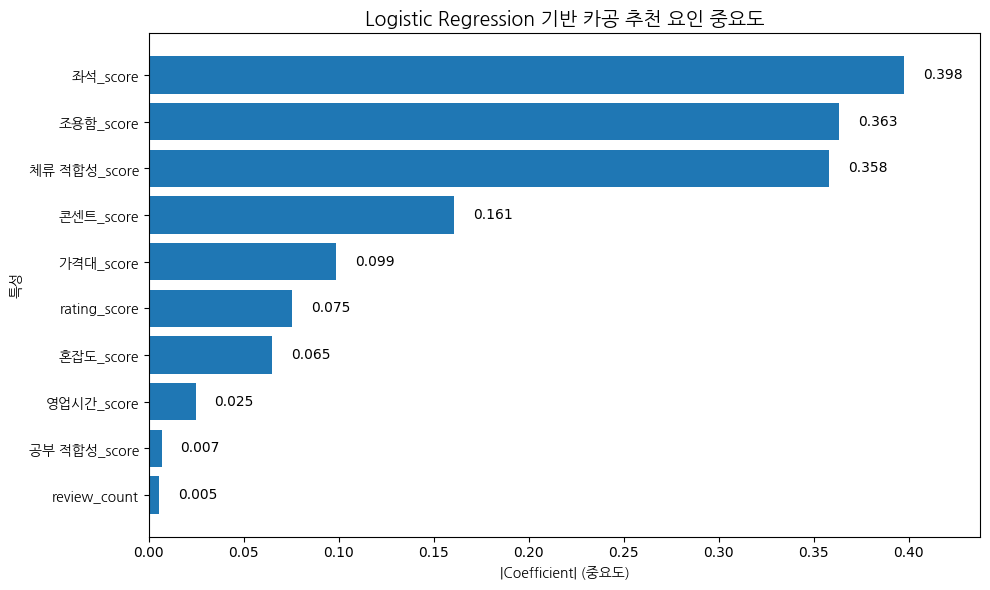

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 폰트 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 중요도 불러오기
importance = pd.read_csv(
    "logistic_importance.csv",
    encoding="utf-8-sig"
)

top10 = (
    importance
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["feature"],
    top10["importance"]
)

plt.gca().invert_yaxis()

# 값 표시
for i, value in enumerate(top10["importance"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(0, top10["importance"].max() * 1.1)

plt.title(
    "Logistic Regression 기반 카공 추천 요인 중요도",
    fontproperties=font_prop,
    fontsize=14
)

plt.xlabel(
    "|Coefficient| (중요도)",
    fontproperties=font_prop
)

plt.ylabel(
    "특성",
    fontproperties=font_prop
)

plt.yticks(fontproperties=font_prop)

plt.tight_layout()

print("그림 1. Logistic Regression 피처 중요도")
plt.show()

In [22]:
def postprocess_review_based_result(
    input_path="study_cafe_final.csv",
    output_path="study_cafe_final_postprocessed.csv",
    top_output_path="study_cafe_recommendation_top.csv",
):

    df = pd.read_csv(
        require_file(input_path)
    )

    # 카공 추천 대상이 아닌 업종 제외
    exclude_terms = [
        "키즈",
        "보드게임",
        "보드빌",
        "레드버튼",
        "팜스보드게임",
        "족욕",
        "찜질",
        "애견",
        "놀이",
        "무인키즈",
        "모래",
        "드로잉",
    ]

    exclude_pattern = "|".join(
        re.escape(term)
        for term in exclude_terms
    )

    df["is_excluded_type"] = (
        df["kakao_name"]
        .astype(str)
        .str.contains(
            exclude_pattern,
            regex=True,
            na=False,
        )
    )

    # 발표용 점수
    # 거리 감점 제거
    df["presentation_score"] = (
        df["adjusted_final_score"]
    ).clip(
        lower=0,
        upper=100
    ).round(2)

    # 발표용 등급
    def presentation_grade(row):

        if row["is_excluded_type"]:
            return "제외"

        score = row["presentation_score"]

        if score >= 90:
            return "카공 성지"

        elif score >= 70:
            return "추천"

        elif score >= 50:
            return "보통"

        else:
            return "비추천"

    df["presentation_grade"] = df.apply(
        presentation_grade,
        axis=1
    )

    # 추천 여부
    df["presentation_recommend_label"] = (
        (
            df["presentation_grade"]
            .isin(
                [
                    "카공 성지",
                    "추천"
                ]
            )
        )
        &
        (
            ~df["is_excluded_type"]
        )
    ).astype(int)

    # 추천 후보
    recommendable = df[
        df["presentation_grade"]
        .isin(
            [
                "카공 성지",
                "추천"
            ]
        )
    ].copy()

    recommendable = recommendable[
        ~recommendable["is_excluded_type"]
    ].copy()

    recommendable = recommendable.sort_values(
        [
            "presentation_score",
            "study_mention_count",
            "review_confidence",
        ],
        ascending=False,
    )

    # 저장
    df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    recommendable.to_csv(
        top_output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"후처리 전체 결과 저장 완료: {output_path}"
    )

    print(
        f"최종 추천 후보 저장 완료: {top_output_path}"
    )

    print("\n후처리 등급 분포")

    display(
        df["presentation_grade"]
        .value_counts()
        .reindex(
            [
                "카공 성지",
                "추천",
                "보통",
                "비추천",
                "제외"
            ],
            fill_value=0
        )
        .reset_index()
    )

    print("\n최종 추천 후보 TOP 10")

    display(
        recommendable[
            [
                "kakao_name",
                "presentation_score",
                "study_sentiment_score",
                "review_confidence",
                "study_mention_count",
                "straight_distance_m",
                "presentation_grade",
            ]
        ]
        .head(10)
    )

    return df, recommendable


postprocessed_result, recommendation_top = (
    postprocess_review_based_result(
        input_path="study_cafe_final.csv",
        output_path="study_cafe_final_postprocessed.csv",
        top_output_path="study_cafe_recommendation_top.csv",
    )
)

후처리 전체 결과 저장 완료: study_cafe_final_postprocessed.csv
최종 추천 후보 저장 완료: study_cafe_recommendation_top.csv

후처리 등급 분포


,presentation_grade,count
0,카공 성지,9
1,추천,11
2,보통,26
3,비추천,12
4,제외,2



최종 추천 후보 TOP 10


,kakao_name,presentation_score,study_sentiment_score,review_confidence,study_mention_count,straight_distance_m,presentation_grade
0,커스텀커피 역북점,99.58,100.00,1.00,3,86,카공 성지
2,드롭탑 용인역북점,98.30,100.00,1.00,1,214,카공 성지
5,지니어스,96.00,100.00,1.00,6,242,카공 성지
3,밀크팜747,96.00,100.00,1.00,1,103,카공 성지
4,커피인류 용인역북점,96.00,100.00,1.00,1,218,카공 성지
7,메가MGC커피 명지대역점,93.75,100.00,1.00,4,424,카공 성지
8,브라운리퀴드,91.19,88.89,1.00,4,107,카공 성지
9,처인재,90.75,100.00,1.00,5,1155,카공 성지
10,트리아농,90.19,100.00,1.00,1,2215,카공 성지
11,카페다 용인시청점,89.05,100.00,0.99,3,2687,추천


## 14. 추천 모델: Random Forest


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
)

def run_random_forest_model(
    score_path="study_cafe_final.csv",
    report_output="rf_report.csv",
    importance_output="rf_importance.csv",
):
    df = pd.read_csv(require_file(score_path))

    if "recommend_label" not in df.columns:
        raise ValueError(
            "recommend_label 컬럼이 필요합니다."
        )

    exclude_pattern = "|".join(
        re.escape(term)
        for term in EXCLUDED_CAFE_TERMS_FOR_FINAL
    )

    df = df[
        ~df["kakao_name"]
        .astype(str)
        .str.contains(
            exclude_pattern,
            regex=True,
            na=False,
        )
    ].copy()

    available_features = [
        col
        for col in MODEL_FEATURES
        if col in df.columns
    ]

    if len(available_features) < 3:
        print("추천 모델에 사용할 피처가 부족합니다.")
        return None

    model_df = df.dropna(
        subset=["recommend_label"]
    ).copy()

    for col in available_features:

        model_df[col] = pd.to_numeric(
            model_df[col],
            errors="coerce",
        )

        model_df[col] = model_df[col].fillna(
            model_df[col].median()
            if not model_df[col].dropna().empty
            else 0
        )

    label_counts = (
        model_df["recommend_label"]
        .value_counts()
    )

    if (
        model_df["recommend_label"].nunique() < 2
        or label_counts.min() < 2
    ):
        print(
            "추천/비추천 라벨 분포가 부족하여 "
            "Random Forest 학습을 건너뜁니다."
        )
        print(label_counts)
        return None

    X = model_df[available_features]
    y = model_df["recommend_label"].astype(int)

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        max_depth=4,
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    scoring = {
        "accuracy": make_scorer(
            accuracy_score
        ),
        "precision": make_scorer(
            precision_score,
            zero_division=0,
        ),
        "recall": make_scorer(
            recall_score,
            zero_division=0,
        ),
        "f1": make_scorer(
            f1_score,
            zero_division=0,
        ),
    }

    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
    )

    # 전체 데이터 재학습
    model.fit(X, y)

    report = pd.DataFrame([
        {
            "model": "Random Forest",
            "n_samples": len(model_df),
            "n_features": len(available_features),
            "accuracy": round(
                cv_result["test_accuracy"].mean(),
                4,
            ),
            "precision": round(
                cv_result["test_precision"].mean(),
                4,
            ),
            "recall": round(
                cv_result["test_recall"].mean(),
                4,
            ),
            "f1": round(
                cv_result["test_f1"].mean(),
                4,
            ),
        }
    ])

    importance = pd.DataFrame({
        "feature": available_features,
        "importance": model.feature_importances_,
    }).sort_values(
        "importance",
        ascending=False,
    )

    report.to_csv(
        report_output,
        index=False,
        encoding="utf-8-sig",
    )

    importance.to_csv(
        importance_output,
        index=False,
        encoding="utf-8-sig",
    )

    print("Random Forest 5-Fold CV 성능")

    display(
        report.rename(
            columns={
                "model": "모델",
                "n_samples": "데이터 수",
                "n_features": "특성 수",
                "accuracy": "Accuracy",
                "precision": "Precision",
                "recall": "Recall",
                "f1": "F1",
            }
        )
    )

    print("\n피처 중요도 TOP 10")

    display(
        importance.head(10).rename(
            columns={
                "feature": "특성",
                "importance": "중요도",
            }
        )
    )

    return report, importance


rf_report, rf_importance = run_random_forest_model(
    score_path="study_cafe_final.csv",
    report_output="rf_report.csv",
    importance_output="rf_importance.csv",
)

Random Forest 5-Fold CV 성능


,모델,데이터 수,특성 수,Accuracy,Precision,Recall,F1
0,Random Forest,60,12,0.8833,0.8529,0.85,0.8278



피처 중요도 TOP 10


,특성,중요도
0,조용함_score,0.325338
2,좌석_score,0.201062
10,review_count,0.150399
4,체류 적합성_score,0.111908
9,rating_score,0.070467
11,review_confidence,0.055048
5,공부 적합성_score,0.029383
6,가격대_score,0.025316
3,혼잡도_score,0.016085
1,콘센트_score,0.010168


그림 2. Random Forest 피처 중요도


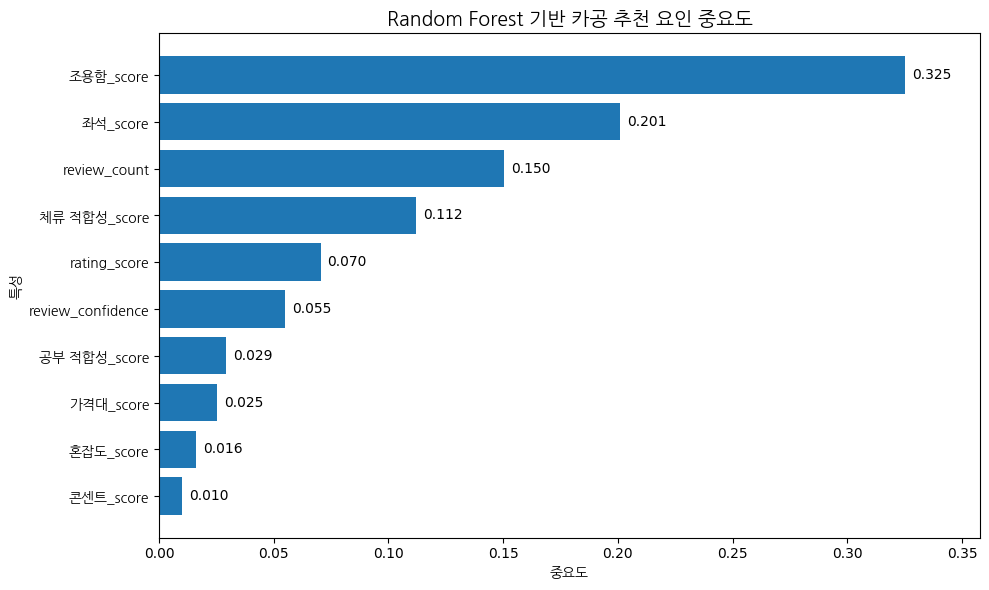

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 폰트 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 중요도 불러오기
importance = pd.read_csv(
    "rf_importance.csv",
    encoding="utf-8-sig"
)

top10 = (
    importance
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["feature"],
    top10["importance"]
)

plt.gca().invert_yaxis()

# 값 표시
for i, value in enumerate(top10["importance"]):
    plt.text(
        value + 0.003,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(0, top10["importance"].max() * 1.1)

plt.title(
    "Random Forest 기반 카공 추천 요인 중요도",
    fontproperties=font_prop,
    fontsize=14
)

plt.xlabel(
    "중요도",
    fontproperties=font_prop
)

plt.ylabel(
    "특성",
    fontproperties=font_prop
)

# 중요!
plt.yticks(fontproperties=font_prop)

plt.tight_layout()

print("그림 2. Random Forest 피처 중요도")
plt.show()

## 15. 추천 모델: XGBoost

In [25]:
!pip install xgboost

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
)

def run_xgboost_model(
    score_path="study_cafe_final.csv",
    report_output="xgb_report.csv",
    importance_output="xgb_importance.csv",
):
    df = pd.read_csv(require_file(score_path))

    if "recommend_label" not in df.columns:
        raise ValueError(
            "recommend_label 컬럼이 필요합니다."
        )

    exclude_pattern = "|".join(
        re.escape(term)
        for term in EXCLUDED_CAFE_TERMS_FOR_FINAL
    )

    df = df[
        ~df["kakao_name"]
        .astype(str)
        .str.contains(
            exclude_pattern,
            regex=True,
            na=False,
        )
    ].copy()

    available_features = [
        col
        for col in MODEL_FEATURES
        if col in df.columns
    ]

    if len(available_features) < 3:
        print("추천 모델에 사용할 피처가 부족합니다.")
        return None

    model_df = df.dropna(
        subset=["recommend_label"]
    ).copy()

    for col in available_features:

        model_df[col] = pd.to_numeric(
            model_df[col],
            errors="coerce",
        )

        model_df[col] = model_df[col].fillna(
            model_df[col].median()
            if not model_df[col].dropna().empty
            else 0
        )

    label_counts = (
        model_df["recommend_label"]
        .value_counts()
    )

    if (
        model_df["recommend_label"].nunique() < 2
        or label_counts.min() < 2
    ):
        print(
            "추천/비추천 라벨 분포가 부족하여 "
            "XGBoost 학습을 건너뜁니다."
        )
        print(label_counts)
        return None

    X = model_df[available_features]
    y = model_df["recommend_label"].astype(int)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
    )

    scoring = {
        "accuracy": make_scorer(
            accuracy_score
        ),
        "precision": make_scorer(
            precision_score,
            zero_division=0,
        ),
        "recall": make_scorer(
            recall_score,
            zero_division=0,
        ),
        "f1": make_scorer(
            f1_score,
            zero_division=0,
        ),
    }

    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
    )

    # 전체 데이터 재학습
    model.fit(X, y)

    report = pd.DataFrame([
        {
            "model": "XGBoost",
            "n_samples": len(model_df),
            "n_features": len(available_features),
            "accuracy": round(
                cv_result["test_accuracy"].mean(),
                4,
            ),
            "precision": round(
                cv_result["test_precision"].mean(),
                4,
            ),
            "recall": round(
                cv_result["test_recall"].mean(),
                4,
            ),
            "f1": round(
                cv_result["test_f1"].mean(),
                4,
            ),
        }
    ])

    importance = pd.DataFrame({
        "feature": available_features,
        "importance": model.feature_importances_,
    }).sort_values(
        "importance",
        ascending=False,
    )

    report.to_csv(
        report_output,
        index=False,
        encoding="utf-8-sig",
    )

    importance.to_csv(
        importance_output,
        index=False,
        encoding="utf-8-sig",
    )

    print("XGBoost 5-Fold CV 성능")

    display(
        report.rename(
            columns={
                "model": "모델",
                "n_samples": "데이터 수",
                "n_features": "특성 수",
                "accuracy": "Accuracy",
                "precision": "Precision",
                "recall": "Recall",
                "f1": "F1",
            }
        )
    )

    print("\n피처 중요도 TOP 10")

    display(
        importance.head(10).rename(
            columns={
                "feature": "특성",
                "importance": "중요도",
            }
        )
    )

    return report, importance


xgb_report, xgb_importance = run_xgboost_model(
    score_path="study_cafe_final.csv",
    report_output="xgb_report.csv",
    importance_output="xgb_importance.csv",
)

XGBoost 5-Fold CV 성능


,모델,데이터 수,특성 수,Accuracy,Precision,Recall,F1
0,XGBoost,60,12,0.8333,0.8433,0.73,0.7566



피처 중요도 TOP 10


,특성,중요도
4,체류 적합성_score,0.341810
0,조용함_score,0.234555
2,좌석_score,0.204001
11,review_confidence,0.082757
9,rating_score,0.063047
10,review_count,0.048955
6,가격대_score,0.024876
1,콘센트_score,0.000000
3,혼잡도_score,0.000000
5,공부 적합성_score,0.000000


그림 3. XGBoost 피처 중요도


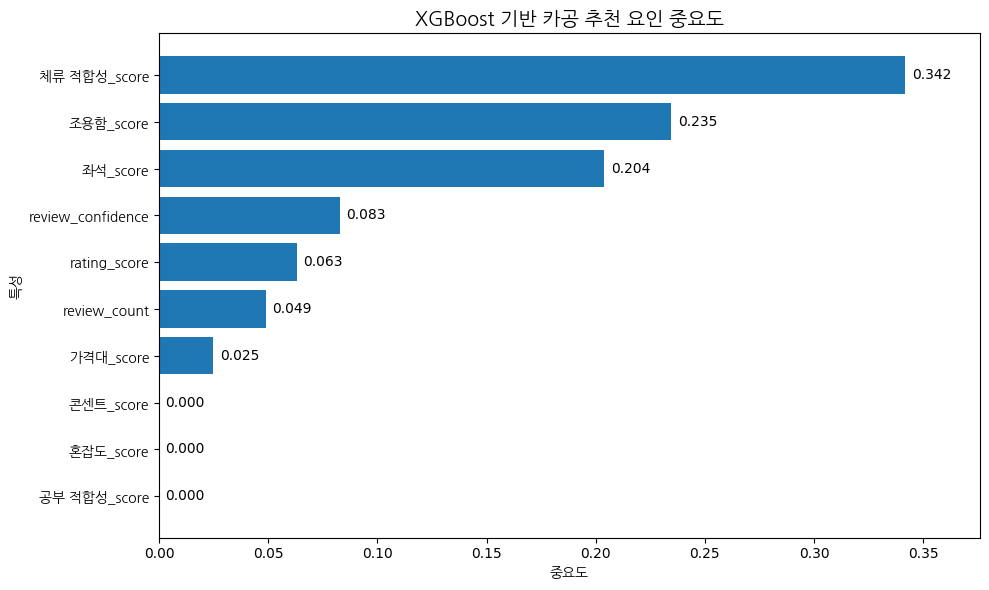

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 폰트 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 중요도 불러오기
importance = pd.read_csv(
    "xgb_importance.csv",
    encoding="utf-8-sig"
)

top10 = (
    importance
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["feature"],
    top10["importance"]
)

plt.gca().invert_yaxis()

# 값 표시
for i, value in enumerate(top10["importance"]):
    plt.text(
        value + 0.003,
        i,
        f"{value:.3f}",
        va="center"
    )

# 오른쪽 여백 확보
plt.xlim(
    0,
    top10["importance"].max() * 1.1
)

plt.title(
    "XGBoost 기반 카공 추천 요인 중요도",
    fontproperties=font_prop,
    fontsize=14
)

plt.xlabel(
    "중요도",
    fontproperties=font_prop
)

plt.ylabel(
    "특성",
    fontproperties=font_prop
)

plt.yticks(fontproperties=font_prop)

plt.tight_layout()

print("그림 3. XGBoost 피처 중요도")
plt.show()

## 16. 모델 성능 비교

In [28]:
def compare_models(
    logistic_report_path="logistic_report.csv",
    rf_report_path="rf_report.csv",
    xgb_report_path="xgb_report.csv",
    output_path="model_comparison.csv",
):

    logistic = pd.read_csv(
        logistic_report_path
    )

    rf = pd.read_csv(
        rf_report_path
    )

    xgb = pd.read_csv(
        xgb_report_path
    )

    comparison = pd.concat(
        [logistic, rf, xgb],
        ignore_index=True,
    )

    comparison = comparison.sort_values(
        "f1",
        ascending=False,
    )

    comparison.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("모델 성능 비교")

    display(
        comparison.rename(
            columns={
                "model": "모델",
                "n_samples": "데이터 수",
                "n_features": "특성 수",
                "accuracy": "Accuracy",
                "precision": "Precision",
                "recall": "Recall",
                "f1": "F1",
            }
        )
    )

    best_model = comparison.iloc[0]

    print("\n최고 성능 모델")

    print("→", best_model["model"])

    return comparison


comparison = compare_models(
    logistic_report_path="logistic_report.csv",
    rf_report_path="rf_report.csv",
    xgb_report_path="xgb_report.csv",
    output_path="model_comparison.csv",
)

모델 성능 비교


,모델,데이터 수,특성 수,Accuracy,Precision,Recall,F1
0,Logistic Regression,60,12,0.9333,0.9429,0.91,0.9159
1,Random Forest,60,12,0.8833,0.8529,0.85,0.8278
2,XGBoost,60,12,0.8333,0.8433,0.73,0.7566



최고 성능 모델
→ Logistic Regression


## 17. 카공 추천에 가장 중요한 요소 도출 (시각화)

그림 4. 2개 이상 모델이 공통적으로 선택한 카공 추천 핵심 요인


,특성,선정 모델 수,평균 중요도
7,조용함_score,3,0.307701
9,체류 적합성_score,3,0.270683
8,좌석_score,3,0.267621
0,rating_score,2,0.069649


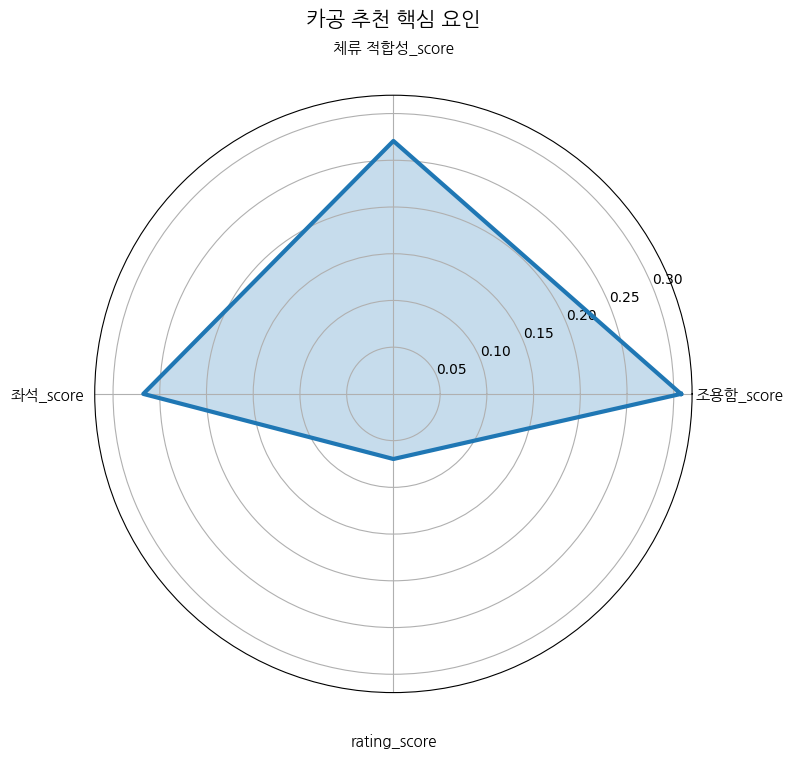

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger(
    "matplotlib.font_manager"
).setLevel(logging.ERROR)

# 폰트 설정
font_path = (
    "/usr/share/fonts/truetype/"
    "nanum/NanumGothic.ttf"
)

font_prop = fm.FontProperties(
    fname=font_path
)

# 중요도 파일 읽기
logistic = pd.read_csv(
    "logistic_importance.csv",
    encoding="utf-8-sig"
)

rf = pd.read_csv(
    "rf_importance.csv",
    encoding="utf-8-sig"
)

xgb = pd.read_csv(
    "xgb_importance.csv",
    encoding="utf-8-sig"
)

# 중요도 병합
merged = (
    logistic[["feature", "importance"]]
    .rename(columns={"importance": "Logistic"})
    .merge(
        rf[["feature", "importance"]]
        .rename(columns={"importance": "RF"}),
        on="feature",
        how="outer"
    )
    .merge(
        xgb[["feature", "importance"]]
        .rename(columns={"importance": "XGB"}),
        on="feature",
        how="outer"
    )
    .fillna(0)
)

# 평균 중요도 계산
merged["avg_importance"] = (
    merged[
        ["Logistic", "RF", "XGB"]
    ]
    .mean(axis=1)
)

# 각 모델 TOP 5
TOP_N = 5

top_logistic = set(
    logistic.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

top_rf = set(
    rf.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

top_xgb = set(
    xgb.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

# 몇 개 모델이 선택했는지 계산
merged["selected_models"] = (
    merged["feature"]
    .apply(
        lambda x:
            int(x in top_logistic)
            + int(x in top_rf)
            + int(x in top_xgb)
    )
)

# 2개 이상 모델이 선택한 피처만 사용
top = (
    merged[
        merged["selected_models"] >= 2
    ]
    .sort_values(
        "avg_importance",
        ascending=False
    )
)

# 레이더 차트 데이터
labels = (
    top["feature"]
    .tolist()
)

values = (
    top["avg_importance"]
    .tolist()
)

labels += [labels[0]]
values += [values[0]]

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=True
)

# 레이더 차트
fig = plt.figure(
    figsize=(8, 8)
)

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    values,
    linewidth=3
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

# 축 설정
ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels[:-1],
    fontproperties=font_prop,
    fontsize=11,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    pad=24
)

plt.title(
    "카공 추천 핵심 요인",
    fontproperties=font_prop,
    fontsize=15,
    pad=50
)

plt.tight_layout()

print(
    "그림 4. 2개 이상 모델이 공통적으로 선택한 카공 추천 핵심 요인"
)

display(
    top[
        [
            "feature",
            "selected_models",
            "avg_importance"
        ]
    ]
    .rename(
        columns={
            "feature": "특성",
            "selected_models": "선정 모델 수",
            "avg_importance": "평균 중요도"
        }
    )
)

plt.show()

## 18. 분석 인사이트

In [30]:
import pandas as pd

comparison = pd.read_csv(
    "model_comparison.csv",
    encoding="utf-8-sig"
)

logistic = pd.read_csv(
    "logistic_importance.csv",
    encoding="utf-8-sig"
)

rf = pd.read_csv(
    "rf_importance.csv",
    encoding="utf-8-sig"
)

xgb = pd.read_csv(
    "xgb_importance.csv",
    encoding="utf-8-sig"
)

# 최고 성능 모델
best_model = comparison.sort_values(
    "f1",
    ascending=False
).iloc[0]

print("분석 인사이트")
print("=" * 125)

print(
    f"1. {best_model['model']} 모델이 "
    f"가장 우수한 성능을 보였다 "
    f"(Accuracy={best_model['accuracy']:.4f}, "
    f"Precision={best_model['precision']:.4f}, "
    f"Recall={best_model['recall']:.4f}, "
    f"F1={best_model['f1']:.4f})."
)

# 세 모델 중요도 통합
merged = (
    logistic[["feature", "importance"]]
    .rename(columns={"importance": "logistic"})
    .merge(
        rf[["feature", "importance"]]
        .rename(columns={"importance": "rf"}),
        on="feature",
        how="outer"
    )
    .merge(
        xgb[["feature", "importance"]]
        .rename(columns={"importance": "xgb"}),
        on="feature",
        how="outer"
    )
    .fillna(0)
)

merged["avg_importance"] = (
    merged["logistic"]
    + merged["rf"]
    + merged["xgb"]
) / 3

# 상위 5개 중요 특성 계산
TOP_N = 5

top_logistic = set(
    logistic.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

top_rf = set(
    rf.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

top_xgb = set(
    xgb.nlargest(
        TOP_N,
        "importance"
    )["feature"]
)

merged["selected_models"] = merged["feature"].apply(
    lambda x:
        int(x in top_logistic)
        + int(x in top_rf)
        + int(x in top_xgb)
)

# 중요도 정렬
merged = merged.sort_values(
    ["selected_models", "avg_importance"],
    ascending=[False, False]
)

# 공통 핵심 요인
common_features = merged[
    merged["selected_models"] >= 2
]

top_features = (
    common_features
    .head(3)["feature"]
    .tolist()
)

print(
    "\n2. 세 모델 분석 결과 "
    + ", ".join(top_features)
    + " 이(가) 공통적으로 중요한 카공 추천 요인으로 나타났다."
)

# 최종 핵심 요약
top_feature = merged.iloc[0]

print(
    f"\n3. 전체 분석 결과 "
    f"{top_feature['feature']}가 "
    f"{int(top_feature['selected_models'])}개 모델에서 "
    f"공통적으로 중요하게 평가되어 "
    f"카공 추천 여부를 결정하는 핵심 요인으로 분석되었다."
)

분석 인사이트
1. Logistic Regression 모델이 가장 우수한 성능을 보였다 (Accuracy=0.9333, Precision=0.9429, Recall=0.9100, F1=0.9159).

2. 세 모델 분석 결과 조용함_score, 체류 적합성_score, 좌석_score 이(가) 공통적으로 중요한 카공 추천 요인으로 나타났다.

3. 전체 분석 결과 조용함_score가 3개 모델에서 공통적으로 중요하게 평가되어 카공 추천 여부를 결정하는 핵심 요인으로 분석되었다.


## 19. 최종 품질 요약

In [31]:
from pathlib import Path
import pandas as pd


def print_analysis_summary():

    print("=" * 70)
    print("방문자 리뷰 기반 분석 파트 결과 요약")
    print("=" * 70)

    files = [
        "sentiment_labeled.csv",
        "sentiment_result.csv",
        "cafe_feature_scores.csv",
        "cafe_scores.csv",
        "study_cafe_final.csv",
        "study_cafe_final_postprocessed.csv",
        "study_cafe_recommendation_top.csv",
        "logistic_report.csv",
        "logistic_importance.csv",
        "rf_report.csv",
        "rf_importance.csv",
        "xgb_report.csv",
        "xgb_importance.csv",
        "model_comparison.csv",
    ]

    # 생성 파일 확인
    print("\n[생성 파일 확인]")

    file_rows = []

    for file in files:

        path = Path(file)

        if path.exists():

            try:
                rows = len(
                    pd.read_csv(file)
                )

            except Exception:
                rows = "-"

            file_rows.append([
                file,
                "존재",
                rows
            ])

        else:

            file_rows.append([
                file,
                "누락",
                "-"
            ])

    display(
        pd.DataFrame(
            file_rows,
            columns=[
                "파일명",
                "상태",
                "행 수"
            ]
        )
    )

    # 최종 결과
    if Path(
        "study_cafe_final.csv"
    ).exists():

        final = pd.read_csv(
            "study_cafe_final.csv"
        )

        print(
            "\n[최종 추천 등급 분포]"
        )

        grade_table = (
            final["grade"]
            .value_counts()
            .reindex(
                [
                    "카공 성지",
                    "추천",
                    "보통",
                    "비추천"
                ],
                fill_value=0
            )
            .reset_index()
        )

        grade_table.columns = [
            "등급",
            "카페 수"
        ]

        display(
            grade_table
        )

        if (
            "recommend_label"
            in final.columns
        ):

            print(
                "\n[추천/비추천 분포]"
            )

            recommend_table = (
                final[
                    "recommend_label"
                ]
                .value_counts()
                .sort_index()
                .reset_index()
            )

            recommend_table.columns = [
                "추천여부",
                "카페 수"
            ]

            recommend_table[
                "추천여부"
            ] = (
                recommend_table[
                    "추천여부"
                ]
                .map({
                    0: "비추천",
                    1: "추천"
                })
            )

            display(
                recommend_table
            )

    # 발표용 결과
    if Path(
        "study_cafe_final_postprocessed.csv"
    ).exists():

        post = pd.read_csv(
            "study_cafe_final_postprocessed.csv"
        )

        if (
            "presentation_grade"
            in post.columns
        ):

            print(
                "\n[발표용 최종 등급 분포]"
            )

            presentation_table = (
                post[
                    "presentation_grade"
                ]
                .value_counts()
                .reindex(
                    [
                        "카공 성지",
                        "추천",
                        "보통",
                        "비추천",
                        "제외"
                    ],
                    fill_value=0
                )
                .reset_index()
            )

            presentation_table.columns = [
                "등급",
                "카페 수"
            ]

            display(
                presentation_table
            )

        if (
            "presentation_recommend_label"
            in post.columns
        ):

            print(
                "\n[발표용 추천/비추천 분포]"
            )

            presentation_recommend_table = (
                post[
                    "presentation_recommend_label"
                ]
                .value_counts()
                .sort_index()
                .reset_index()
            )

            presentation_recommend_table.columns = [
                "추천여부",
                "카페 수"
            ]

            presentation_recommend_table[
                "추천여부"
            ] = (
                presentation_recommend_table[
                    "추천여부"
                ]
                .map({
                    0: "비추천",
                    1: "추천"
                })
            )

            display(
                presentation_recommend_table
            )

            # 추천 비율
            print(
                "\n[발표용 추천 비율]"
            )

            recommend_count = (
                post[
                    "presentation_recommend_label"
                ]
                .sum()
            )

            total_count = len(
                post
            )

            recommend_rate = round(
                recommend_count
                / total_count
                * 100,
                1
            )

            display(
                pd.DataFrame([{
                    "전체 카페 수":
                        total_count,
                    "추천 카페 수":
                        recommend_count,
                    "추천 비율(%)":
                        recommend_rate
                }])
            )

    # 모델 성능 비교
    if Path(
        "model_comparison.csv"
    ).exists():

        comparison = pd.read_csv(
            "model_comparison.csv"
        )

        print(
            "\n[모델 성능 비교]"
        )

        display(
            comparison
        )

        if len(
            comparison
        ) > 0:

            best_model = (
                comparison
                .sort_values(
                    "f1",
                    ascending=False
                )
                .iloc[0]
            )

            print(
                "\n[최고 성능 모델]"
            )

            display(
                pd.DataFrame({
                    "최고 성능 모델": [
                        best_model[
                            "model"
                        ]
                    ]
                })
            )

    print("\n")
    print("=" * 70)
    print("분석 요약 완료")
    print("=" * 70)


print_analysis_summary()

방문자 리뷰 기반 분석 파트 결과 요약

[생성 파일 확인]


,파일명,상태,행 수
0,sentiment_labeled.csv,존재,139
1,sentiment_result.csv,존재,137
2,cafe_feature_scores.csv,존재,91
3,cafe_scores.csv,존재,60
4,study_cafe_final.csv,존재,60
5,study_cafe_final_postprocessed.csv,존재,60
6,study_cafe_recommendation_top.csv,존재,20
7,logistic_report.csv,존재,1
8,logistic_importance.csv,존재,12
9,rf_report.csv,존재,1



[최종 추천 등급 분포]


,등급,카페 수
0,카공 성지,11
1,추천,11
2,보통,26
3,비추천,12



[추천/비추천 분포]


...


[모델 성능 비교]


,model,n_samples,n_features,accuracy,precision,recall,f1
0,Logistic Regression,60,12,0.9333,0.9429,0.91,0.9159
1,Random Forest,60,12,0.8833,0.8529,0.85,0.8278
2,XGBoost,60,12,0.8333,0.8433,0.73,0.7566



[최고 성능 모델]


,최고 성능 모델
0,Logistic Regression




분석 요약 완료


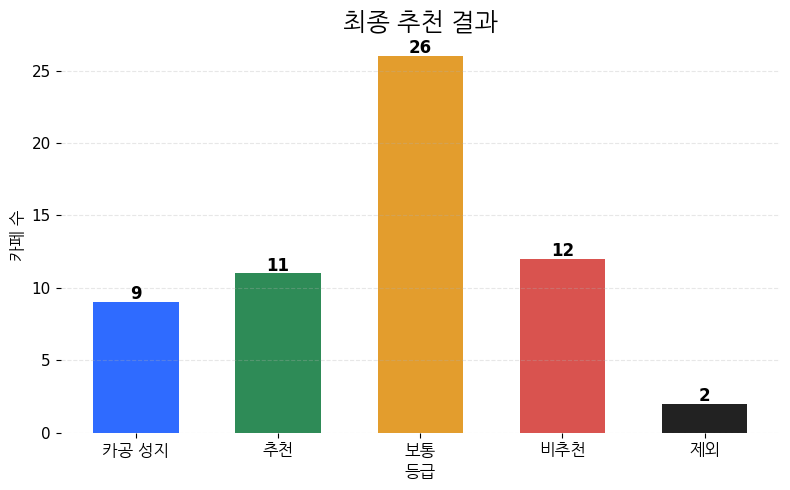

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger(
    "matplotlib.font_manager"
).setLevel(logging.ERROR)

# 폰트 설정
font_path = (
    "/usr/share/fonts/truetype/"
    "nanum/NanumGothic.ttf"
)

font_prop = fm.FontProperties(
    fname=font_path
)

# 데이터 읽기
post = pd.read_csv(
    "study_cafe_final_postprocessed.csv",
    encoding="utf-8-sig"
)

# 등급 분포
grade_counts = (
    post["presentation_grade"]
    .value_counts()
    .reindex(
        [
            "카공 성지",
            "추천",
            "보통",
            "비추천",
            "제외"
        ],
        fill_value=0
    )
)

# 색상
colors = [
    "#2F6BFF",  # 카공 성지 (파랑)
    "#2E8B57",  # 추천 (초록)
    "#E39D2D",  # 보통 (주황)
    "#D9534F",  # 비추천 (빨강)
    "#222222"   # 제외 (검정)
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    grade_counts.index,
    grade_counts.values,
    color=colors,
    width=0.6
)

# 막대 위 숫자 표시
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        str(int(height)),
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "최종 추천 결과",
    fontproperties=font_prop,
    fontsize=18
)

plt.xlabel(
    "등급",
    fontproperties=font_prop,
    fontsize=12
)

plt.ylabel(
    "카페 수",
    fontproperties=font_prop,
    fontsize=12
)

# x축 한글 폰트 적용
plt.xticks(
    fontproperties=font_prop,
    fontsize=12
)

# y축 숫자 크기
plt.yticks(
    fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.box(False)

plt.tight_layout()

plt.show()

## 20. 지도 시각화

전체 지도

In [33]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from urllib.parse import quote

# 데이터 로드
df = pd.read_csv(
    "study_cafe_final_postprocessed.csv",
    encoding="utf-8-sig"
)

# 제외 카페 제거
df = df[
    df["presentation_grade"] != "제외"
].copy()

# 지도 생성
center_lat = df["latitude"].mean()
center_lon = df["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14
)

cluster = MarkerCluster().add_to(m)

# 등급 색상
color_map = {
    "카공 성지": "blue",
    "추천": "green",
    "보통": "orange",
    "비추천": "red",
}

# 마커 생성
for _, row in df.iterrows():

    features = {
        "조용함": row["조용함_score"],
        "좌석": row["좌석_score"],
        "콘센트": row["콘센트_score"],
        "체류 적합성": row["체류 적합성_score"],
        "공부 적합성": row["공부 적합성_score"],
    }

    top3 = sorted(
        features.items(),
        key=lambda x: x[1],
        reverse=True
    )[:3]

    top3_text = "<br>".join(
        [f"• {name}" for name, _ in top3]
    )

    business_hours = row.get(
        "business_hours",
        "정보 없음"
    )

    if pd.isna(business_hours):
        business_hours = "정보 없음"

    rating = row.get(
        "rating",
        "정보 없음"
    )

    if pd.isna(rating):
        rating = "정보 없음"

    review_count = row.get(
        "review_count",
        0
    )

    if pd.isna(review_count):
        review_count = 0

    distance_text = (
        f"{int(row['straight_distance_m'])}m"
        if not pd.isna(
            row["straight_distance_m"]
        )
        else "정보 없음"
    )

    # 네이버 URL
    naver_url = row.get(
        "naver_map_url",
        None
    )

    if (
        pd.isna(naver_url)
        or not str(naver_url).startswith("http")
    ):
        naver_url = (
            "https://map.naver.com/p/search/"
            + quote(
                str(
                    row["kakao_name"]
                )
            )
        )

    popup_html = f"""
    <div style="
    width:220px;
    font-size:13px;
    line-height:1.4;
    text-align:center;
">

    <h4 style="
    margin-bottom:8px;
    text-align:center;
">
    <h3>[{row['kakao_name']}]</h3>

    🏆 <b>등급</b> :
    {row['presentation_grade']}<br>

    ⭐ <b>카공 점수</b> :
    {row['presentation_score']:.2f}<br><br>

    🕒 <b>영업시간</b> :
    {business_hours}<br><br>

    ⭐ <b>별점</b> :
    {rating}<br>

    📝 <b>리뷰 수</b> :
    {int(review_count)}개<br><br>

    📍 <b>용인대와 직선거리</b> :
    {distance_text}<br><br>

    <b>주요 장점 TOP3</b><br>
    {top3_text}<br><br>

    <a href="{naver_url}"
       target="_blank"
       style="
       background:#03C75A;
       color:white;
       padding:8px 12px;
       text-decoration:none;
       border-radius:5px;">
       네이버 검색
    </a>

    </div>
    """

    folium.Marker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        popup=folium.Popup(
            popup_html,
            max_width=400
        ),
        tooltip=(
            f"{row['kakao_name']} "
            f"({row['presentation_grade']})"
        ),
        icon=folium.Icon(
            color=color_map.get(
                row["presentation_grade"],
                "blue"
            )
        )
    ).add_to(cluster)

    # 용인대학교 표시
    folium.Marker(
        location=[37.2276, 127.1677],
        popup="용인대학교",
        tooltip="용인대학교",
        icon=folium.Icon(
            color="purple",
            icon="star",
            prefix="glyphicon"
        )
    ).add_to(m)

m

추천 전용 지도  
(카공 성지 + 추천)

In [34]:
# 추천 카페만 필터링
recommend_df = df[
    df["presentation_grade"].isin(
        ["카공 성지", "추천"]
    )
].copy()

print(
    f"추천 지도 표시 카페 수: {len(recommend_df)}개"
)

# 추천 지도 생성
recommend_map = folium.Map(
    location=[
        recommend_df["latitude"].mean(),
        recommend_df["longitude"].mean()
    ],
    zoom_start=14
)

cluster = MarkerCluster().add_to(
    recommend_map
)

# 추천 전용 색상
recommend_color = {
    "카공 성지": "blue",
    "추천": "green",
}

# 마커 생성
for _, row in recommend_df.iterrows():

    popup_html = f"""
    <div style="
    width:220px;
    font-size:13px;
    line-height:1.4;
    text-align:center;
">

    <h4 style="
    margin-bottom:8px;
    text-align:center;
">
    <h3>[{row['kakao_name']}]</h3>

    🏆 <b>등급</b> :
    {row['presentation_grade']}<br>

    ⭐ <b>카공 점수</b> :
    {row['presentation_score']:.2f}<br><br>

    🕒 <b>영업시간</b> :
    {business_hours}<br><br>

    ⭐ <b>별점</b> :
    {rating}<br>

    📝 <b>리뷰 수</b> :
    {int(review_count)}개<br><br>

    📍 <b>용인대와 직선거리</b> :
    {distance_text}<br><br>

    <b>주요 장점 TOP3</b><br>
    {top3_text}<br><br>

    <a href="{naver_url}"
       target="_blank"
       style="
       background:#03C75A;
       color:white;
       padding:8px 12px;
       text-decoration:none;
       border-radius:5px;">
       네이버 검색
    </a>

    </div>
    """

    folium.Marker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        popup=folium.Popup(
            popup_html,
            max_width=250
        ),
        tooltip=(
            f"{row['kakao_name']} "
            f"({row['presentation_grade']})"
        ),
        icon=folium.Icon(
            color=recommend_color[
                row["presentation_grade"]
            ]
        )
    ).add_to(cluster)

    # 용인대학교 표시
    folium.Marker(
        location=[37.2276, 127.1677],
        popup="용인대학교",
        tooltip="용인대학교",
        icon=folium.Icon(
            color="purple",
            icon="star",
            prefix="glyphicon"
        )
    ).add_to(recommend_map)

recommend_map

추천 지도 표시 카페 수: 20개
